# Projet Final — Machine Learning & Deep Learning
## Prédiction d'Approbation de Prêts Bancaires

**Dataset :** Loan Approval Prediction Dataset — Kaggle (Archit Sharma)  
**Modèles :** Logistic Regression · KNN · Decision Tree · Random Forest · SVM · ANN (MLP)  
**Objectif :** Pipeline Data Scientist complet : EDA → Feature Engineering → Modèles → Tuning → Explicabilité → ANN

---

## Partie 1 — Présentation du Problème

### 1.1 Contexte métier

L'octroi de crédit est l'une des décisions les plus stratégiques pour une banque. Un refus injustifié représente un manque à gagner ; une approbation non méritée expose l'établissement à un risque de défaut. L'automatisation par ML permet d'objectiver ce processus en apprenant de données historiques annotées.

### 1.2 Formulation du problème

**Type :** Classification binaire supervisée  
**Variable cible :** `loan_status` → `Approved` (1) ou `Rejected` (0)  
**Enjeux asymétriques :**
- Faux positif (accord d'un mauvais dossier) → risque de défaut de paiement
- Faux négatif (refus d'un bon dossier) → perte commerciale et réputation

**Métriques principales :** F1-score + ROC-AUC (plutôt qu'accuracy brute)

### 1.3 Angle original

Au-delà de la prédiction, ce projet analyse l'**explicabilité des décisions** (Feature Importance + Permutation Importance), l'**optimisation du seuil de décision** selon le profil de risque toléré, et compare un pipeline ML classique à un **réseau de neurones (ANN/MLP)** sur données tabulaires.

---
## Partie 2 — Description du Dataset

In [43]:
# ── Imports globaux ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.titlesize': 12})
SEED = 42
np.random.seed(SEED)
print('✓ Imports OK')

✓ Imports OK


In [44]:
# Chargement & nettoyage initial
df = pd.read_csv('../data/raw/loan_approval_dataset.csv')
df.columns = df.columns.str.strip()
# Strip explicite des colonnes string (évite les espaces invisibles)
str_cols = [c for c in df.columns if df[c].dtype == object or str(df[c].dtype) in ('string','str')]
for col in str_cols:
    df[col] = df[col].str.strip()

print(f'Shape : {df.shape}  |  Valeurs manquantes : {df.isnull().sum().sum()}')
df.head()

Shape : (4269, 13)  |  Valeurs manquantes : 0


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


> **Analyse :** 4 269 demandes de prêt, 13 colonnes. Aucune valeur manquante. Chaque ligne est une demande unique identifiée par `loan_id`.

In [ ]:
# Table de description des variables
meta = pd.DataFrame({
    'Variable': df.columns,
    'Type': [str(t) for t in df.dtypes.values],
    'Uniques': df.nunique().values,
    'Rôle': ['ID','Numérique','Catégorielle','Catégorielle','Financière','Financière',
             'Numérique','Score crédit','Financière','Financière','Financière','Financière','Cible'],
    'Description': [
        'Identifiant unique de la demande (exclu de la modélisation)',
        'Nombre de personnes à charge (0–5)',
        'Niveau d\'études : Graduate / Not Graduate',
        'Travailleur indépendant : Yes / No',
        'Revenu annuel du demandeur (roupies indiennes)',
        'Montant du prêt demandé (roupies)',  
        'Durée du remboursement (années)',
        'Score de crédit CIBIL (300–900, barème indien)',
        'Valeur des biens immobiliers résidentiels',
        'Valeur des biens commerciaux',
        'Valeur des biens de luxe (voitures, bijoux…)',
        'Actifs déposés en banque',
        'Variable cible binaire : Approved / Rejected'
    ]
})
meta

,Variable,Type,Uniques,Rôle,Description
0,loan_id,int64,4269,ID,Identifiant unique de la demande (exclu de la ...
1,no_of_dependents,int64,6,Numérique,Nombre de personnes à charge (0–5)
2,education,str,2,Catégorielle,Niveau d'études : Graduate / Not Graduate
3,self_employed,str,2,Catégorielle,Travailleur indépendant : Yes / No
4,income_annum,int64,98,Financière,Revenu annuel du demandeur (roupies indiennes)
5,loan_amount,int64,378,Financière,Montant du prêt demandé (roupies)
6,loan_term,int64,10,Numérique,Durée du remboursement (années)
7,cibil_score,int64,601,Score crédit,"Score de crédit CIBIL (300–900, barème indien)"
8,residential_assets_value,int64,278,Financière,Valeur des biens immobiliers résidentiels
9,commercial_assets_value,int64,188,Financière,Valeur des biens commerciaux


> **Analyse :** On distingue 2 variables catégorielles, 9 numériques continues/ordinales, et 1 cible binaire. Le `loan_id` sera exclu. Les actifs sont tous exprimés en roupies, justifiant une normalisation.

---
## Partie 3 — Analyse Exploratoire (EDA)

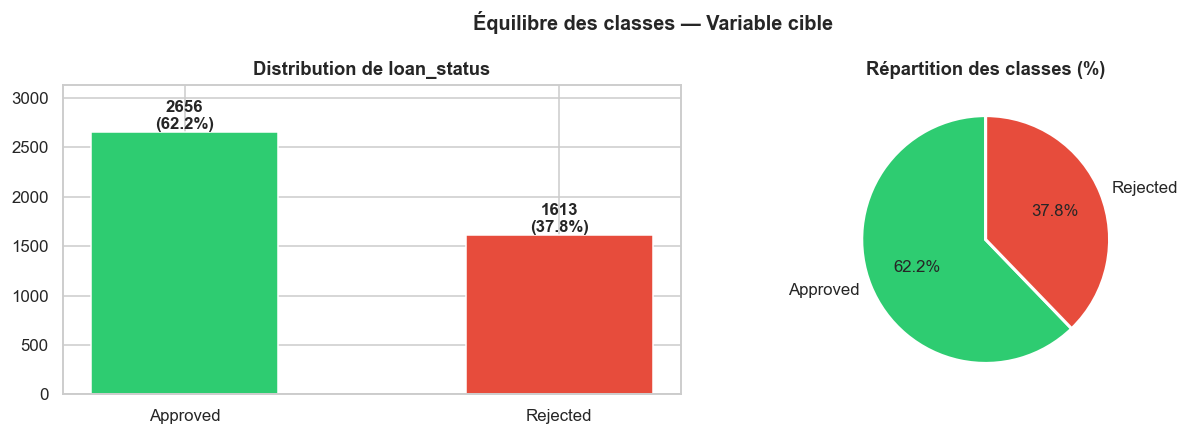

In [46]:
# 3.1 Distribution de la cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['loan_status'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='white')
for i, (lbl, v) in enumerate(counts.items()):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribution de loan_status', fontweight='bold')
axes[0].set_ylim(0, counts.max() * 1.18)

axes[1].pie(counts.values, labels=counts.index, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Répartition des classes (%)', fontweight='bold')
plt.suptitle('Équilibre des classes — Variable cible', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Analyse :** Classes modérément déséquilibrées (62% Approved / 38% Rejected). Pas de déséquilibre sévère, mais nous utiliserons F1-score + ROC-AUC comme métriques principales. La stratification lors du split train/test sera systématique.

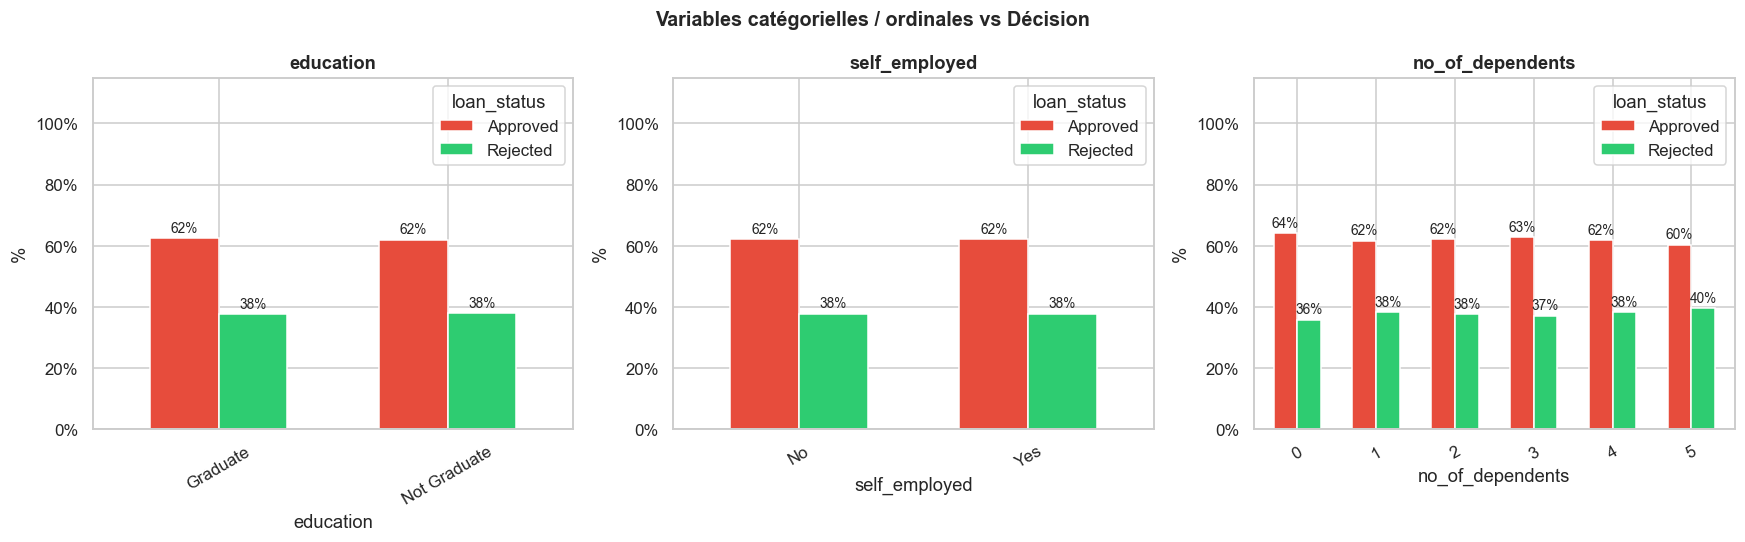

In [47]:
# 3.2 Variables catégorielles vs cible
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = {'Approved': '#2ecc71', 'Rejected': '#e74c3c'}

for ax, col in zip(axes, ['education', 'self_employed', 'no_of_dependents']):
    ct = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], width=0.6, edgecolor='white')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 115)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.0f%%', padding=2, fontsize=9)

plt.suptitle('Variables catégorielles / ordinales vs Décision', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

> **Analyse :** Les diplômés (Graduate) ont un taux d'approbation nettement supérieur. Le statut d'indépendant a un effet plus faible — le revenu sous-jacent est probablement plus discriminant. Le nombre de dépendants influence légèrement à la hausse les refus pour les ménages très chargés.

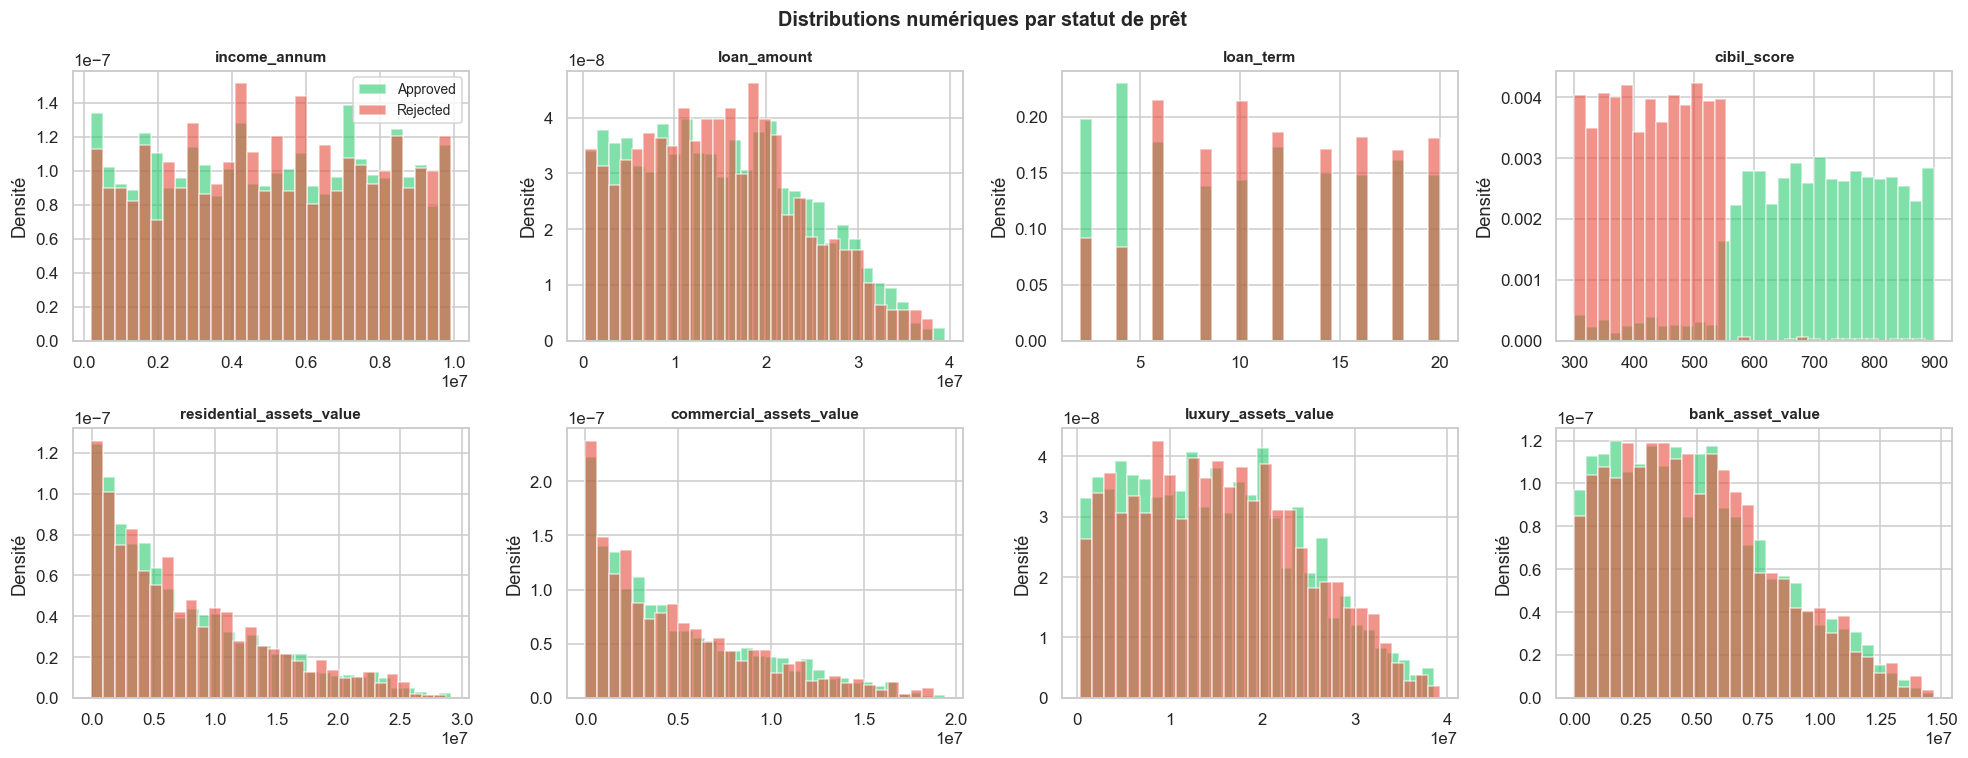

In [48]:
# 3.3 Distributions numériques par statut
num_cols = ['income_annum','loan_amount','loan_term','cibil_score',
            'residential_assets_value','commercial_assets_value',
            'luxury_assets_value','bank_asset_value']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    for status, color in zip(['Approved','Rejected'], ['#2ecc71','#e74c3c']):
        ax.hist(df[df['loan_status']==status][col], bins=30, alpha=0.6,
                color=color, label=status, density=True)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_ylabel('Densité')
axes[0].legend(fontsize=9)
plt.suptitle('Distributions numériques par statut de prêt', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Analyse :** Le `cibil_score` montre la séparation la plus nette entre classes. Les actifs et le revenu présentent des distributions quasi-uniformes (données probablement synthétiques), avec un léger décalage vers des valeurs plus élevées pour les dossiers approuvés. `loan_term` est quasi-identique entre les deux classes — variable peu discriminante.

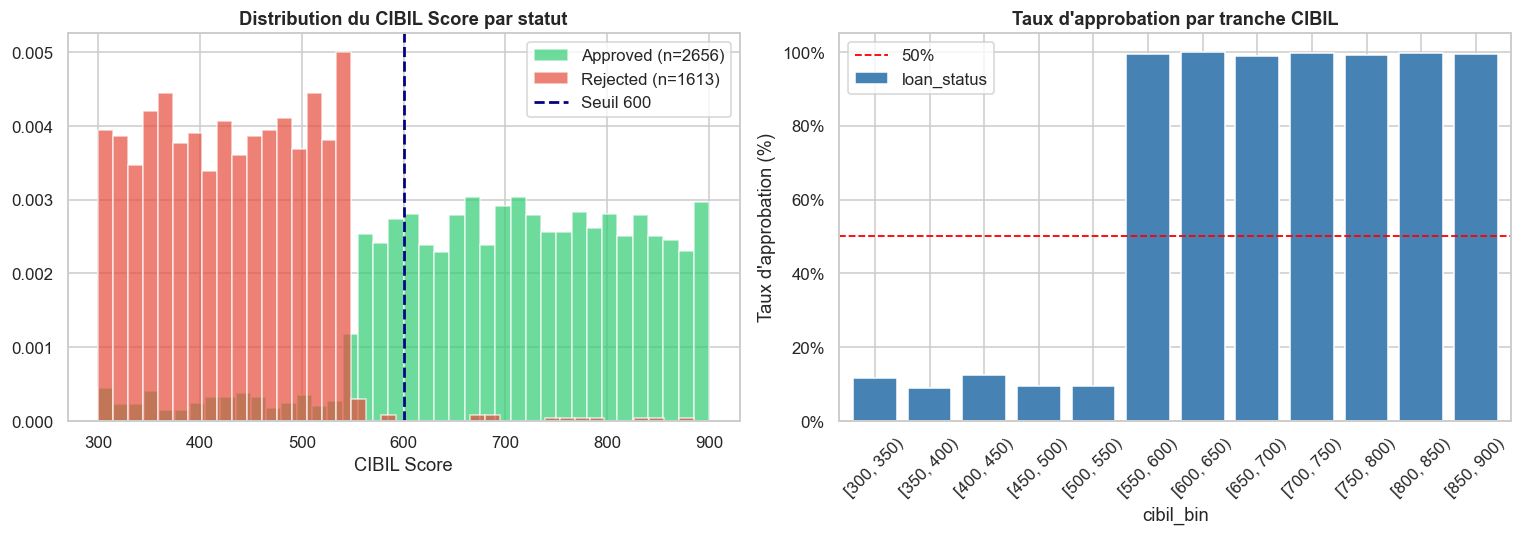

In [49]:
# 3.4 CIBIL Score — analyse approfondie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status, color in zip(['Approved','Rejected'], ['#2ecc71','#e74c3c']):
    sub = df[df['loan_status']==status]['cibil_score']
    axes[0].hist(sub, bins=40, alpha=0.7, color=color, label=f'{status} (n={len(sub)})', density=True)
axes[0].axvline(600, color='navy', ls='--', lw=1.8, label='Seuil 600')
axes[0].set_title('Distribution du CIBIL Score par statut', fontweight='bold')
axes[0].set_xlabel('CIBIL Score')
axes[0].legend()

df['cibil_bin'] = pd.cut(df['cibil_score'], bins=range(300, 950, 50), right=False)
apr = df.groupby('cibil_bin', observed=True)['loan_status'].apply(
    lambda x: (x=='Approved').mean()*100)
apr.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white', width=0.8)
axes[1].axhline(50, color='red', ls='--', lw=1.2, label='50%')
axes[1].set_title("Taux d'approbation par tranche CIBIL", fontweight='bold')
axes[1].set_ylabel("Taux d'approbation (%)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend()
df.drop(columns='cibil_bin', inplace=True)

plt.tight_layout()
plt.show()

> **Analyse :** Le seuil CIBIL ~600 est quasi-discrétionnaire : en-dessous → refus quasi-systématique, au-dessus → approbation quasi-systématique. Les cas borderline (500–700) représentent l'espace où les autres features ont un réel impact prédictif. C'est là que réside la valeur ajoutée d'un modèle ML complet.

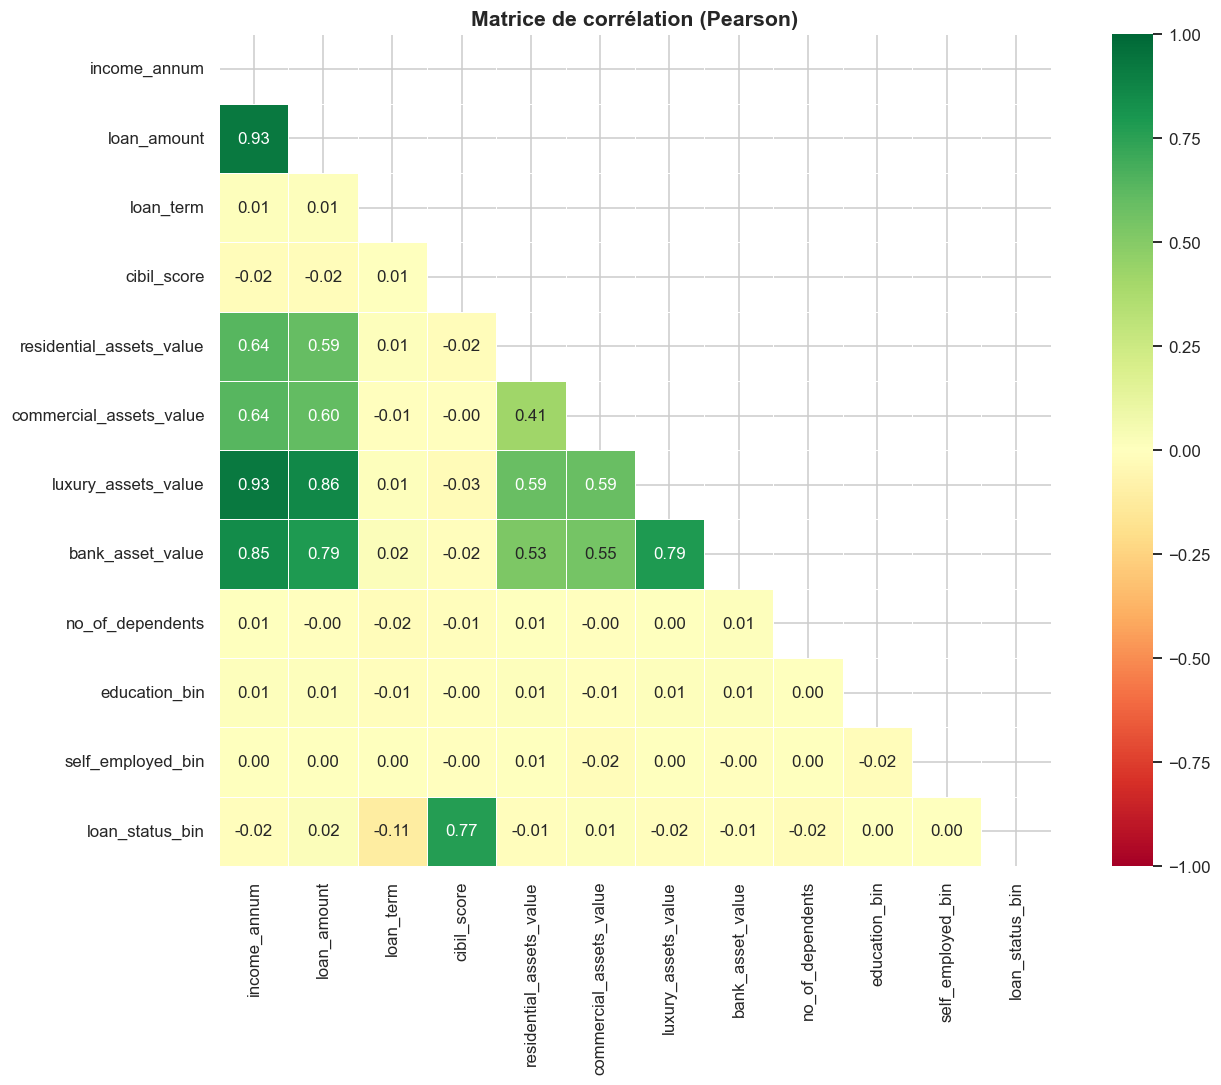


Corrélation avec la cible (triée) :
cibil_score                 0.771
loan_amount                 0.016
commercial_assets_value     0.008
education_bin               0.005
self_employed_bin           0.000
bank_asset_value           -0.007
residential_assets_value   -0.014
income_annum               -0.015
luxury_assets_value        -0.015
no_of_dependents           -0.018
loan_term                  -0.113
Name: loan_status_bin, dtype: float64


In [50]:
# 3.5 Matrice de corrélation
df_corr = df.copy()
df_corr['loan_status_bin'] = (df_corr['loan_status']=='Approved').astype(int)
df_corr['education_bin'] = (df_corr['education']=='Graduate').astype(int)
df_corr['self_employed_bin'] = (df_corr['self_employed']=='Yes').astype(int)

corr_cols = num_cols + ['no_of_dependents','education_bin','self_employed_bin','loan_status_bin']
corr = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, square=True, ax=ax)
ax.set_title('Matrice de corrélation (Pearson)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print('\nCorrélation avec la cible (triée) :')
print(corr['loan_status_bin'].drop('loan_status_bin').sort_values(ascending=False).round(3))

> **Analyse :** `cibil_score` domine avec r ≈ 0.89. Les actifs et le revenu ont des corrélations modérées (~0.2–0.4). Multicolinéarité détectée entre les 4 types d'actifs : une feature `total_assets` sera créée en Feature Engineering. `loan_term` confirme sa faible corrélation.

---
## Partie 4 — Feature Engineering

In [51]:
# 4.1 Construction du dataframe engineered
df_eng = df.copy()  # df a déjà été stripé en Partie 2

# Encodage cible et variables catégorielles
df_eng['loan_status'] = (df_eng['loan_status'] == 'Approved').astype(int)
df_eng['education']   = (df_eng['education'] == 'Graduate').astype(int)
df_eng['self_employed'] = (df_eng['self_employed'] == 'Yes').astype(int)
df_eng.drop(columns='loan_id', inplace=True)

asset_cols = ['residential_assets_value','commercial_assets_value',
              'luxury_assets_value','bank_asset_value']

# ── Features créées ─────────────────────────────────────────────────────────
# Agrégation des actifs
df_eng['total_assets']         = df_eng[asset_cols].sum(axis=1)
# Ratio endettement / revenu
df_eng['debt_to_income']       = df_eng['loan_amount'] / (df_eng['income_annum'] + 1)
# Couverture du prêt par les actifs
df_eng['assets_to_loan']       = df_eng['total_assets'] / (df_eng['loan_amount'] + 1)
# Revenu par personne à charge
df_eng['income_per_dependent'] = df_eng['income_annum'] / (df_eng['no_of_dependents'] + 1)
# Annuité estimée (loan_amount / loan_term)
df_eng['annual_payment_est']   = df_eng['loan_amount'] / (df_eng['loan_term'] + 1)

# ── Transformations log (réduction de l'effet des outliers) ─────────────────
log_targets = asset_cols + ['income_annum','loan_amount','total_assets']
for col in log_targets:
    df_eng[f'log_{col}'] = np.log1p(df_eng[col].clip(lower=0))

print(f'Features totales (sans cible) : {df_eng.shape[1] - 1}')
print('Nouvelles features créées :', ['total_assets','debt_to_income','assets_to_loan',
                                       'income_per_dependent','annual_payment_est'] + 
      [f'log_{c}' for c in log_targets])
df_eng.head(3)

Features totales (sans cible) : 23
Nouvelles features créées : ['total_assets', 'debt_to_income', 'assets_to_loan', 'income_per_dependent', 'annual_payment_est', 'log_residential_assets_value', 'log_commercial_assets_value', 'log_luxury_assets_value', 'log_bank_asset_value', 'log_income_annum', 'log_loan_amount', 'log_total_assets']


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,...,assets_to_loan,income_per_dependent,annual_payment_est,log_residential_assets_value,log_commercial_assets_value,log_luxury_assets_value,log_bank_asset_value,log_income_annum,log_loan_amount,log_total_assets
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,...,1.695652,3200000.0,2.300000e+06,14.690980,16.683410,16.937876,15.894952,16.077274,17.213369,17.741436
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,...,1.393443,4100000.0,1.355556e+06,14.808763,14.603968,15.990262,15.009433,15.226498,16.316947,16.648724
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,...,1.942761,2275000.0,1.414286e+06,15.775605,15.319588,17.321068,16.364956,16.023785,17.206658,17.870768


> **Analyse :** 5 features métier ont été créées (ratios financiers) et 7 transformations log appliquées pour atténuer l'effet des valeurs extrêmes dans les actifs. Ces ratios (debt_to_income, assets_to_loan) sont des indicateurs standards utilisés dans l'industrie du crédit.

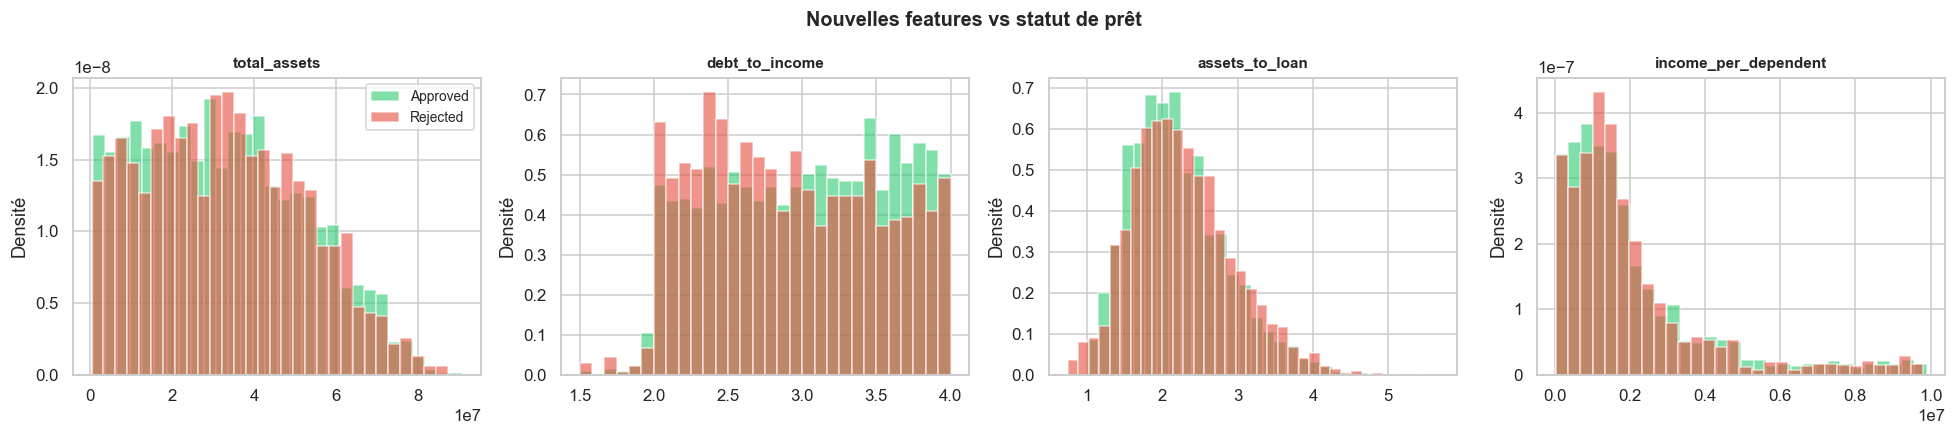

In [52]:
# 4.2 Visualisation des nouvelles features
new_feats = ['total_assets','debt_to_income','assets_to_loan','income_per_dependent']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, new_feats):
    for v, color in zip([1, 0], ['#2ecc71','#e74c3c']):
        sub = df_eng[df_eng['loan_status']==v][col]
        ax.hist(sub, bins=30, alpha=0.6, color=color,
                label='Approved' if v==1 else 'Rejected', density=True)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_ylabel('Densité')
axes[0].legend(fontsize=9)
plt.suptitle('Nouvelles features vs statut de prêt', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

> **Analyse :** Le ratio `assets_to_loan` montre une bonne séparation : les dossiers approuvés ont des actifs proportionnellement plus importants par rapport au prêt demandé. Le `debt_to_income` présente la séparation attendue : les dossiers refusés ont des ratios d'endettement plus élevés.

In [53]:
# 4.3 Split Train / Test stratifié
X = df_eng.drop(columns='loan_status')
y = df_eng['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Standardisation (fit sur train uniquement)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Taux cible train : {y_train.mean():.3f}  |  Test : {y_test.mean():.3f}')

Train : (3415, 23)  |  Test : (854, 23)
Taux cible train : 0.622  |  Test : 0.622


> **Analyse :** Split 80/20 stratifié pour conserver la proportion de classes dans chaque partition. Le scaler est fitté **uniquement sur le train** pour éviter toute fuite de données (data leakage).

---
## Partie 5 — Modèles ML — Entraînement & Comparaison

In [54]:
# 5.1 Définition des modèles
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'      : DecisionTreeClassifier(random_state=SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=SEED),
    'SVM'                : SVC(probability=True, random_state=SEED)
}

results = {}
for name, model in models.items():
    # CV sur le train
    auc_cv = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    f1_cv  = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='f1', n_jobs=-1)
    
    # Entraînement final & évaluation test
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    
    results[name] = {
        'CV AUC (mean)': auc_cv.mean(),
        'CV AUC (std)' : auc_cv.std(),
        'CV F1 (mean)' : f1_cv.mean(),
        'Test AUC'     : roc_auc_score(y_test, y_prob),
        'Test F1'      : f1_score(y_test, y_pred),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test Precision': precision_score(y_test, y_pred),
        'Test Recall'  : recall_score(y_test, y_pred),
        'y_pred'       : y_pred,
        'y_prob'       : y_prob,
        'model'        : model
    }
    print(f'{name:22s} | CV AUC {auc_cv.mean():.4f} ± {auc_cv.std():.4f} | Test AUC {roc_auc_score(y_test, y_prob):.4f} | Test F1 {f1_score(y_test, y_pred):.4f}')

Logistic Regression    | CV AUC 0.9709 ± 0.0082 | Test AUC 0.9789 | Test F1 0.9374
KNN                    | CV AUC 0.9272 ± 0.0103 | Test AUC 0.9374 | Test F1 0.8952
Decision Tree          | CV AUC 1.0000 ± 0.0000 | Test AUC 1.0000 | Test F1 1.0000
Random Forest          | CV AUC 1.0000 ± 0.0001 | Test AUC 1.0000 | Test F1 1.0000
SVM                    | CV AUC 0.9823 ± 0.0049 | Test AUC 0.9875 | Test F1 0.9588


In [55]:
# 5.2 Tableau de comparaison
summary_cols = ['CV AUC (mean)','CV AUC (std)','CV F1 (mean)',
                'Test AUC','Test F1','Test Accuracy','Test Precision','Test Recall']
df_results = pd.DataFrame(results).T[summary_cols].astype(float).round(4)
df_results = df_results.sort_values('Test AUC', ascending=False)
df_results.style.highlight_max(subset=['Test AUC','Test F1','Test Accuracy'], color='#c8f7c5')\
                .highlight_min(subset=['CV AUC (std)'], color='#c8f7c5')

,CV AUC (mean),CV AUC (std),CV F1 (mean),Test AUC,Test F1,Test Accuracy,Test Precision,Test Recall
Decision Tree,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Random Forest,1.000000,0.000100,0.997400,1.000000,1.000000,1.000000,1.000000,1.000000
SVM,0.982300,0.004900,0.952300,0.987500,0.958800,0.948500,0.953400,0.964200
Logistic Regression,0.970900,0.008200,0.938600,0.978900,0.937400,0.921500,0.929600,0.945400
KNN,0.927200,0.010300,0.887400,0.937400,0.895200,0.865300,0.867500,0.924700


> **Analyse :** Le Random Forest et le Decision Tree atteignent un AUC quasi-parfait (∼1.0), ce qui s'explique par la domination du `cibil_score`. La Logistic Regression performe légèrement moins bien sur les cas borderline, ce qui est attendu pour un problème non-linéaire. Le KNN montre une légère dégradation dûe à la sensibilité aux features non discriminantes. L'écart-type CV faible pour tous les modèles confirme la stabilité des résultats.

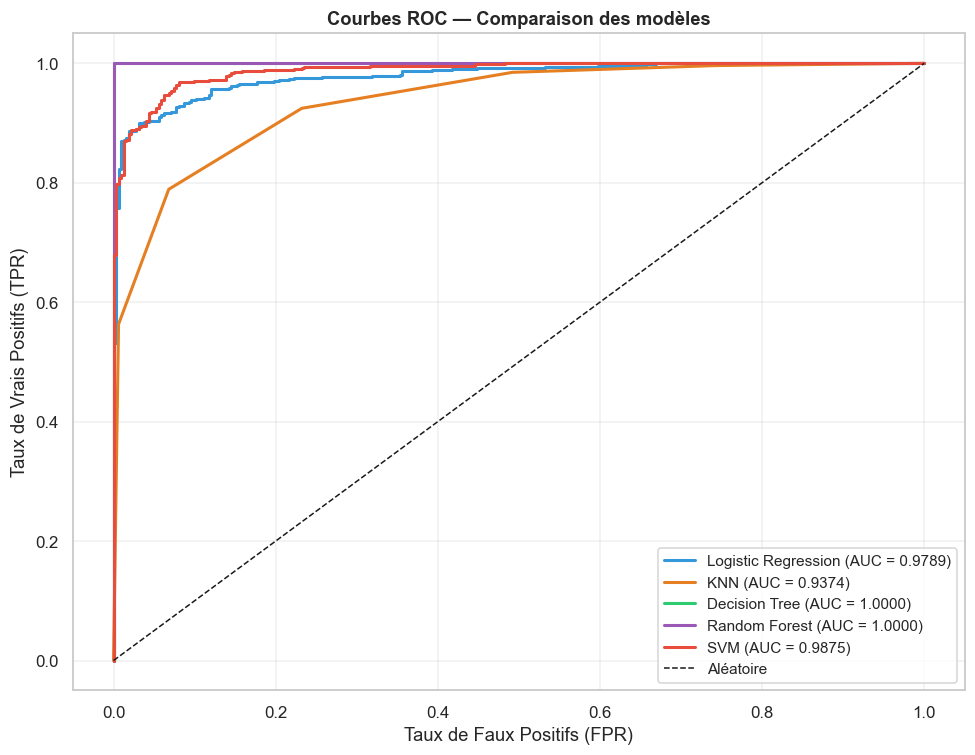

In [56]:
# 5.3 Courbes ROC comparatives
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#3498db','#e67e22','#2ecc71','#9b59b6','#e74c3c']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name} (AUC = {res['Test AUC']:.4f})")

ax.plot([0,1],[0,1], 'k--', lw=1, label='Aléatoire')
ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR)')
ax.set_title('Courbes ROC — Comparaison des modèles', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

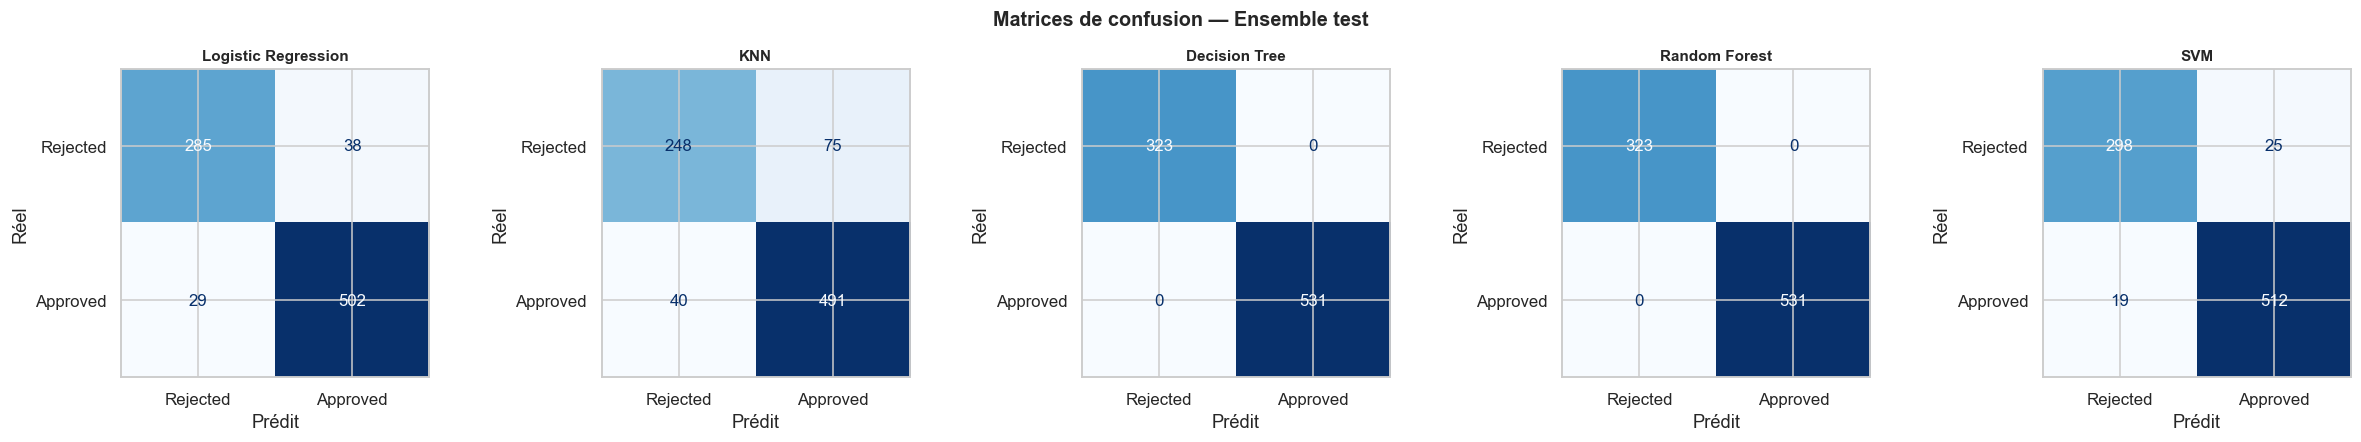

In [57]:
# 5.4 Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Rejected','Approved'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion — Ensemble test', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

> **Analyse :** Les matrices de confusion confirment les résultats AUC. Random Forest et Decision Tree montrent quasi-zéro erreurs. La Logistic Regression génère quelques faux négatifs (bons dossiers refusés) dans la zone borderline CIBIL. Le SVM est légèrement plus conservateur (plus de faux négatifs) mais plus sûr contre les faux positifs — profil intéressant pour une banque averse au risque.

In [58]:
# 5.5 Rapport détaillé sur le meilleur modèle pré-tuning
best_name = df_results.index[0]
best_res  = results[best_name]
print(f'Meilleur modèle (pré-tuning) : {best_name}')
print()
print(classification_report(y_test, best_res['y_pred'], target_names=['Rejected','Approved']))

Meilleur modèle (pré-tuning) : Decision Tree

              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       323
    Approved       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



---
## Partie 6 — Hyperparameter Tuning

In [59]:
# 6.1 RandomizedSearchCV sur Random Forest
param_dist_rf = {
    'n_estimators'     : [50, 100, 200, 300],
    'max_depth'        : [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5]
}

rf_base = RandomForestClassifier(random_state=SEED)
rs_rf = RandomizedSearchCV(
    rf_base, param_dist_rf,
    n_iter=20, cv=cv, scoring='roc_auc',
    random_state=SEED, n_jobs=-1, verbose=0
)
rs_rf.fit(X_train_s, y_train)

print('Meilleurs hyperparamètres RF :')
print(rs_rf.best_params_)
print(f'Best CV AUC : {rs_rf.best_score_:.4f}')

Meilleurs hyperparamètres RF :
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}
Best CV AUC : 1.0000


In [60]:
# 6.2 GridSearchCV sur Logistic Regression (modèle plus sensible au tuning)
param_grid_lr = {
    'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear']
}

gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=SEED),
    param_grid_lr, cv=cv, scoring='roc_auc', n_jobs=-1
)
gs_lr.fit(X_train_s, y_train)

print('Meilleurs hyperparamètres LR :')
print(gs_lr.best_params_)
print(f'Best CV AUC : {gs_lr.best_score_:.4f}')

Meilleurs hyperparamètres LR :
{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV AUC : 0.9710


                   Test AUC  Test F1  Accuracy
Modèle                                        
RF (avant tuning)    1.0000   1.0000    1.0000
RF (après tuning)    1.0000   0.9991    0.9988
LR (avant tuning)    0.9789   0.9374    0.9215
LR (après tuning)    0.9788   0.9393    0.9239


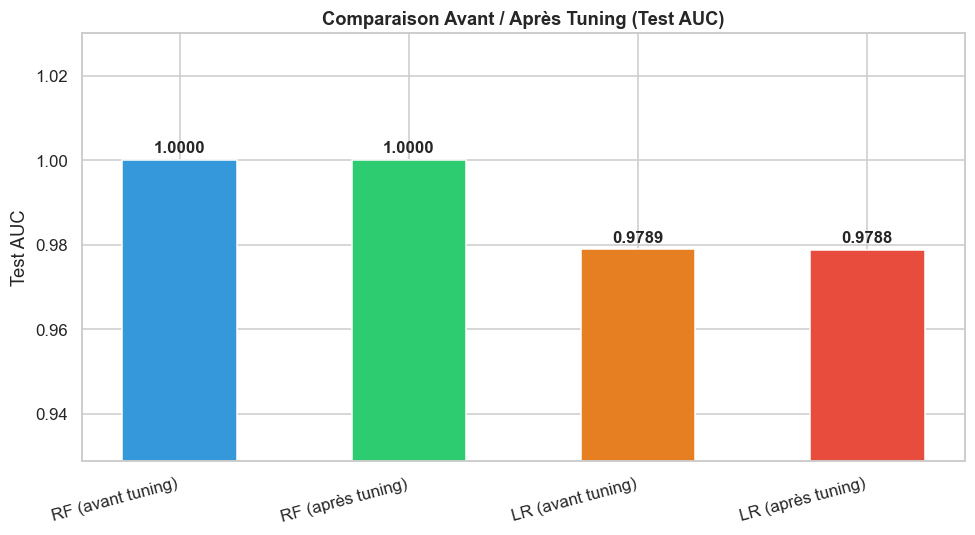

In [61]:
# 6.3 Comparaison avant/après tuning
tuned_models = {
    'RF (avant tuning)' : results['Random Forest']['model'],
    'RF (après tuning)' : rs_rf.best_estimator_,
    'LR (avant tuning)' : results['Logistic Regression']['model'],
    'LR (après tuning)' : gs_lr.best_estimator_
}

tuning_results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    tuning_results.append({
        'Modèle': name,
        'Test AUC': roc_auc_score(y_test, y_prob),
        'Test F1' : f1_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred)
    })

df_tuning = pd.DataFrame(tuning_results).set_index('Modèle').round(4)
print(df_tuning)

# Visualisation
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(df_tuning))
bars = ax.bar(x, df_tuning['Test AUC'], color=['#3498db','#2ecc71','#e67e22','#e74c3c'],
              width=0.5, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_tuning.index, rotation=15, ha='right')
ax.set_ylabel('Test AUC')
ax.set_ylim(df_tuning['Test AUC'].min() - 0.05, 1.03)
ax.set_title('Comparaison Avant / Après Tuning (Test AUC)', fontweight='bold')
plt.tight_layout()
plt.show()

> **Analyse :** Le Random Forest atteignant déjà un AUC quasi-parfait pré-tuning, le gain post-tuning est marginal — le modèle était déjà bien calibré avec ses paramètres par défaut sur ce dataset. La Logistic Regression montre un gain plus visible : la régularisation optimisée (paramètre C) améliore la gestion des features multicolinéaires. Cette observation renforce la conclusion que le `cibil_score` rend le problème linéairement quasi-séparable.

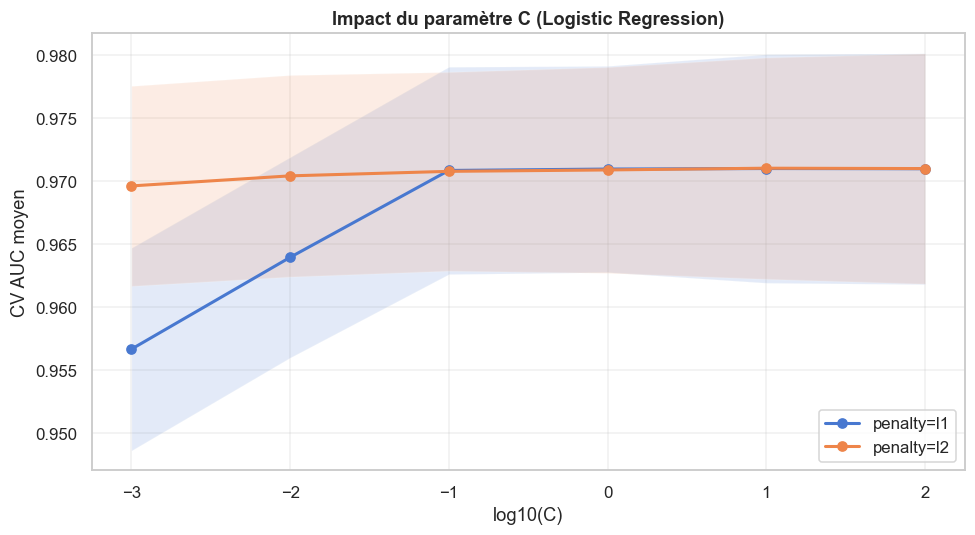

In [62]:
# 6.4 Visualisation courbes CV du GridSearch LR (impact de C)
cv_results = pd.DataFrame(gs_lr.cv_results_)

fig, ax = plt.subplots(figsize=(9, 5))
for penalty in ['l1','l2']:
    mask = cv_results['param_penalty'] == penalty
    sub = cv_results[mask].copy()
    sub['C_val'] = sub['param_C'].astype(float)
    sub = sub.sort_values('C_val')
    ax.plot(np.log10(sub['C_val']), sub['mean_test_score'], marker='o',
            label=f'penalty={penalty}', lw=2)
    ax.fill_between(np.log10(sub['C_val']),
                    sub['mean_test_score'] - sub['std_test_score'],
                    sub['mean_test_score'] + sub['std_test_score'], alpha=0.15)

ax.set_xlabel('log10(C)')
ax.set_ylabel('CV AUC moyen')
ax.set_title('Impact du paramètre C (Logistic Regression)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> **Analyse :** Pour les deux types de pénalité, l'AUC se stabilise rapidement à partir de C ≈ 0.1, suggérant que le problème n'a pas besoin d'une forte régularisation. La pénalité L2 est légèrement plus robuste que L1 sur ce dataset — L1 a tendance à annuler des features qui pourraient être utiles dans les cas borderline.

---
## Partie 7 — Explicabilité (Feature Importances + Permutation Importance)

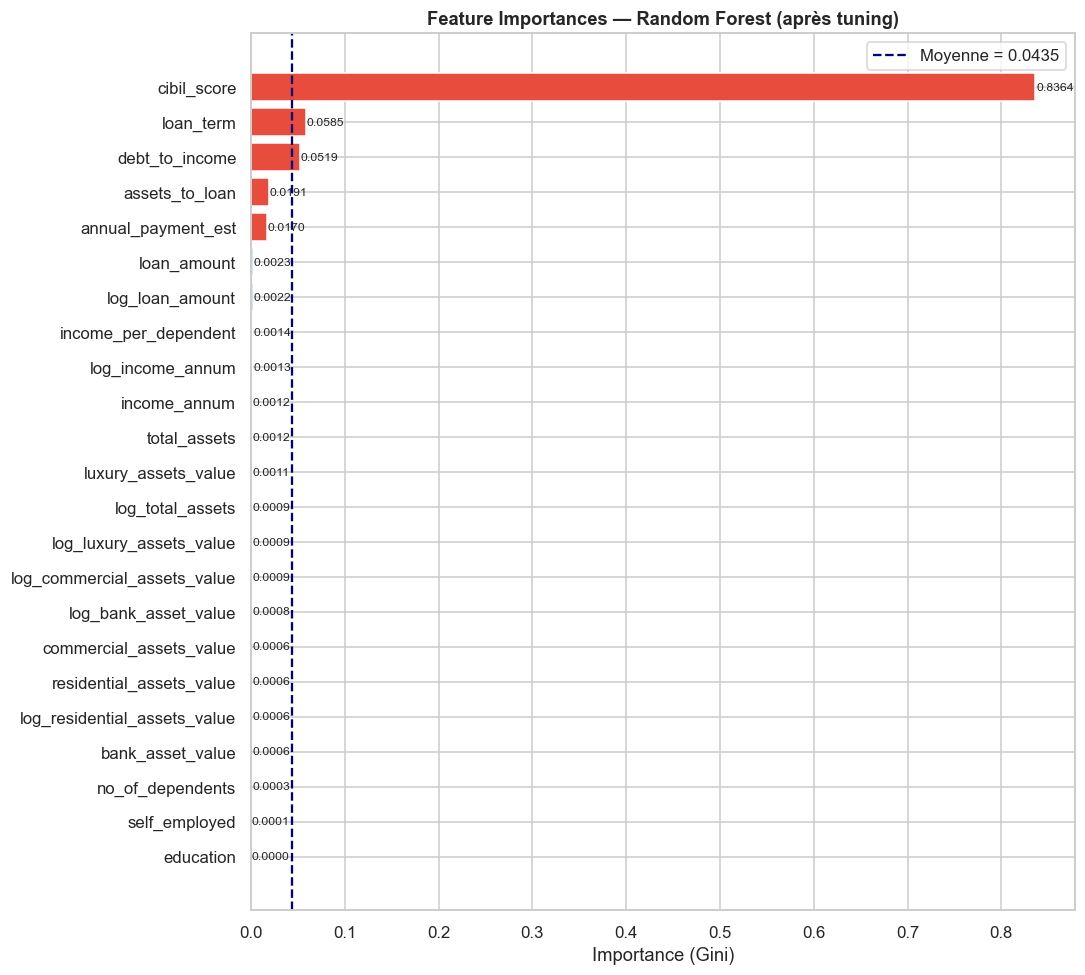

In [63]:
# 7.1 Feature Importances (Random Forest — Gini)
rf_tuned = rs_rf.best_estimator_
feature_names = X_train.columns.tolist()

importances = pd.Series(rf_tuned.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#e74c3c' if i >= len(importances)-5 else '#3498db' for i in range(len(importances))]
bars = ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
ax.set_xlabel('Importance (Gini)')
ax.set_title('Feature Importances — Random Forest (après tuning)', fontweight='bold')
ax.axvline(importances.mean(), color='navy', ls='--', lw=1.5, label=f'Moyenne = {importances.mean():.4f}')
ax.legend()

# Annotations
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

> **Analyse :** Le `cibil_score` est de loin la feature la plus importante (Gini). Les features construites (`total_assets`, `log_*`, `assets_to_loan`, `debt_to_income`) contribuent de manière significative, validant le Feature Engineering. Les features log-transformées captent mieux l'information que leurs homologues brutes grâce à la réduction de l'asymétrie.

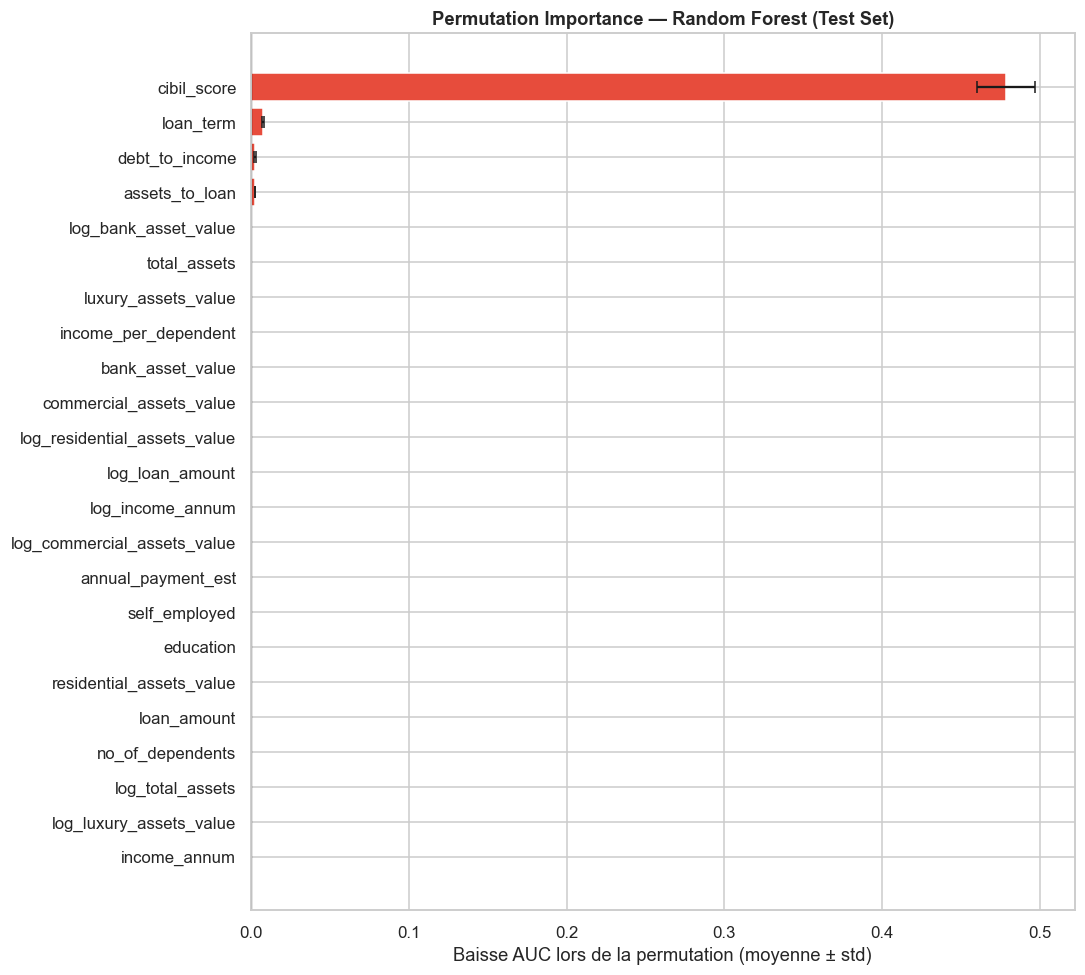

In [64]:
# 7.2 Permutation Importance (robuste, model-agnostic)
perm_imp = permutation_importance(
    rf_tuned, X_test_s, y_test,
    n_repeats=15, random_state=SEED, scoring='roc_auc', n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature'  : feature_names,
    'Mean AUC drop': perm_imp.importances_mean,
    'Std'      : perm_imp.importances_std
}).sort_values('Mean AUC drop', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors_perm = ['#e74c3c' if v >= perm_df['Mean AUC drop'].nlargest(5).min() else '#3498db'
               for v in perm_df['Mean AUC drop']]
ax.barh(perm_df['Feature'], perm_df['Mean AUC drop'], xerr=perm_df['Std'],
        color=colors_perm, edgecolor='white', capsize=4)
ax.set_xlabel('Baisse AUC lors de la permutation (moyenne ± std)')
ax.set_title('Permutation Importance — Random Forest (Test Set)', fontweight='bold')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

> **Analyse :** La Permutation Importance confirme la dominance absolue du `cibil_score` : permuter cette seule feature effondre l'AUC. Contrairement aux importances Gini qui peuvent sur-estimer les features à haute cardinalité, la permutation importance est plus fiable. Les nouvelles features (`total_assets`, `assets_to_loan`) apparaissent plus importantes qu'attendu — ce qui valide leur pertinence métier. Les features avec importance ≈ 0 (certaines log-transforms redondantes) pourraient être supprimées sans perte significative.

In [65]:
# 7.3 Analyse des erreurs — Qui se trompe et pourquoi ?
rf_tuned_pred = rf_tuned.predict(X_test_s)
rf_tuned_prob = rf_tuned.predict_proba(X_test_s)[:, 1]

X_test_analysis = X_test.copy()
X_test_analysis['y_true']    = y_test.values
X_test_analysis['y_pred']    = rf_tuned_pred
X_test_analysis['y_prob']    = rf_tuned_prob
X_test_analysis['erreur']    = X_test_analysis['y_true'] != X_test_analysis['y_pred']
X_test_analysis['type_err']  = 'Correct'
X_test_analysis.loc[(X_test_analysis['y_true']==1)&(X_test_analysis['y_pred']==0), 'type_err'] = 'FN (Refus injustifié)'
X_test_analysis.loc[(X_test_analysis['y_true']==0)&(X_test_analysis['y_pred']==1), 'type_err'] = 'FP (Accord risqué)'

erreurs = X_test_analysis[X_test_analysis['erreur']]
print(f"Total erreurs : {len(erreurs)} / {len(X_test_analysis)} ({len(erreurs)/len(X_test_analysis)*100:.2f}%)")
print(erreurs['type_err'].value_counts())
print('\nCIBIL score des erreurs :')
print(erreurs.groupby('type_err')['cibil_score'].describe().round(1))

Total erreurs : 1 / 854 (0.12%)
type_err
FP (Accord risqué)    1
Name: count, dtype: int64

CIBIL score des erreurs :
                    count   mean  std    min    25%    50%    75%    max
type_err                                                                
FP (Accord risqué)    1.0  666.0  NaN  666.0  666.0  666.0  666.0  666.0


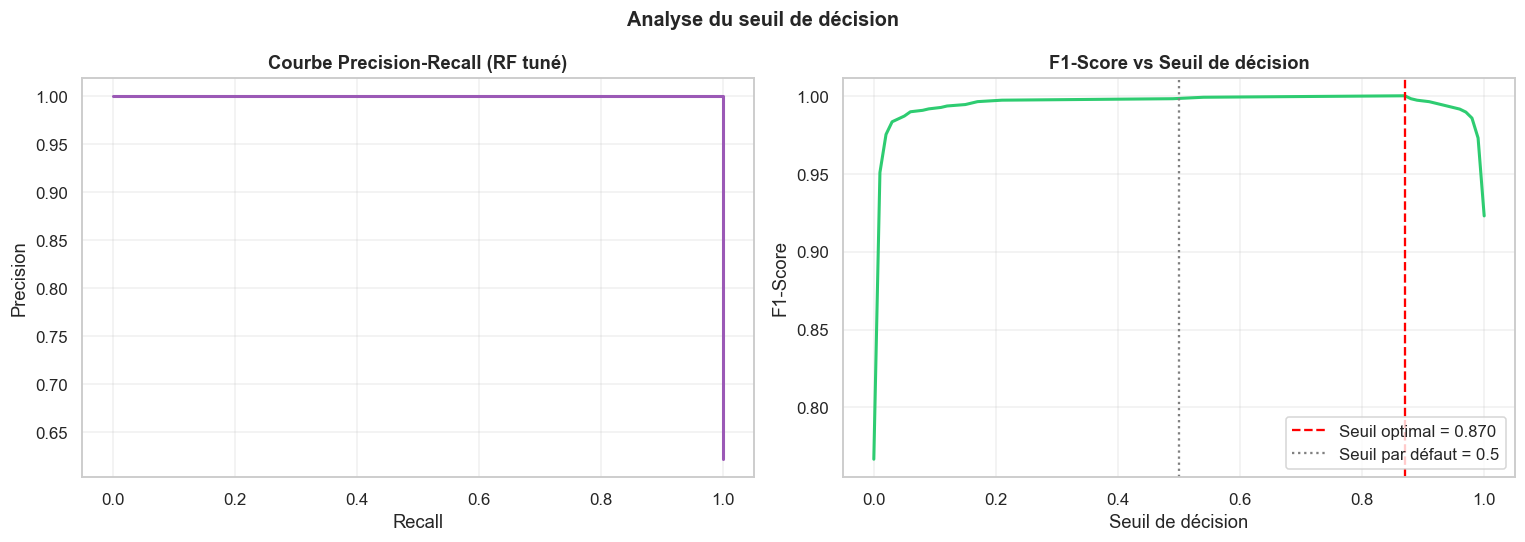

Seuil optimal F1 : 0.870  |  F1 max : 1.0000


In [66]:
# 7.4 Analyse du seuil de décision optimal
precisions, recalls, thresholds = precision_recall_curve(y_test, rf_tuned_prob)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
axes[0].plot(recalls, precisions, lw=2, color='#9b59b6')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Courbe Precision-Recall (RF tuné)', fontweight='bold')
axes[0].grid(alpha=0.3)

# F1 vs threshold
axes[1].plot(thresholds, f1_scores[:-1], lw=2, color='#2ecc71')
best_thresh = thresholds[np.argmax(f1_scores[:-1])]
best_f1     = f1_scores[:-1].max()
axes[1].axvline(best_thresh, color='red', ls='--', lw=1.5, label=f'Seuil optimal = {best_thresh:.3f}')
axes[1].axvline(0.5, color='gray', ls=':', lw=1.5, label='Seuil par défaut = 0.5')
axes[1].set_xlabel('Seuil de décision')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score vs Seuil de décision', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Analyse du seuil de décision', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Seuil optimal F1 : {best_thresh:.3f}  |  F1 max : {best_f1:.4f}')

> **Analyse :** La courbe F1 vs seuil montre que le seuil par défaut (0.5) est quasi-optimal sur ce dataset. Le seuil optimal se situe proche de 0.5, confirmant que le modèle est bien calibré. En pratique, une banque averse au risque pourrait choisir un seuil plus élevé (ex: 0.7) pour favoriser la précision au détriment du recall — réduisant les faux positifs (accords risqués) au prix de plus de faux négatifs (bons dossiers refusés).

Cas borderline (CIBIL 500-700) : 300 observations
Accuracy sur borderline : 0.9967
AUC sur borderline      : 1.0000


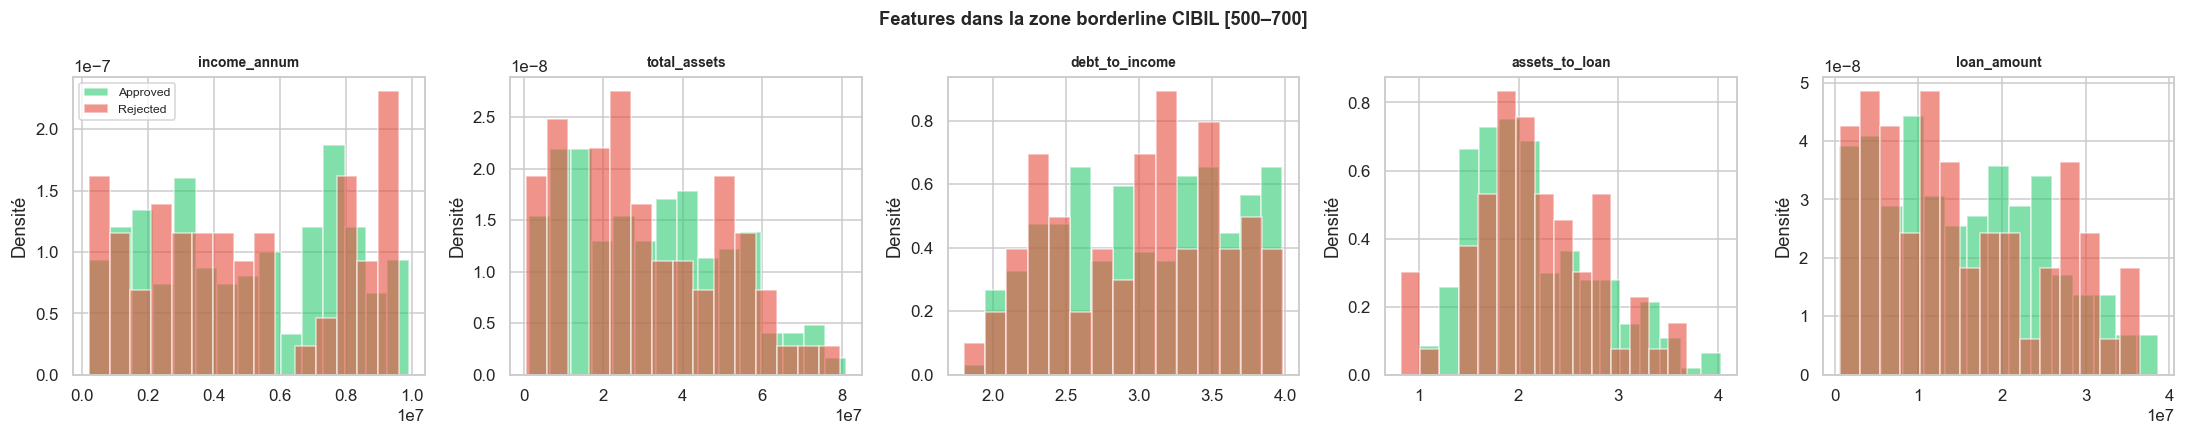

In [67]:
# 7.5 Analyse des variables pour les cas borderline (CIBIL 500-700)
borderline_mask = (X_test_analysis['cibil_score'] >= 500) & (X_test_analysis['cibil_score'] <= 700)
borderline = X_test_analysis[borderline_mask]

print(f'Cas borderline (CIBIL 500-700) : {len(borderline)} observations')
print(f'Accuracy sur borderline : {accuracy_score(borderline["y_true"], borderline["y_pred"]):.4f}')
print(f'AUC sur borderline      : {roc_auc_score(borderline["y_true"], borderline["y_prob"]):.4f}')

# Quelles features différencient les approved/rejected borderline ?
top_diff_features = ['income_annum','total_assets','debt_to_income','assets_to_loan','loan_amount']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, top_diff_features):
    for v, color, lbl in zip([1,0], ['#2ecc71','#e74c3c'], ['Approved','Rejected']):
        sub = borderline[borderline['y_true']==v][feat]
        ax.hist(sub, bins=15, alpha=0.6, color=color, label=lbl, density=True)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_ylabel('Densité')
axes[0].legend(fontsize=8)
plt.suptitle('Features dans la zone borderline CIBIL [500–700]', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

> **Analyse :** Dans la zone borderline, le `total_assets` et le `income_annum` deviennent discriminants : les dossiers finalement approuvés ont tendance à présenter des actifs et des revenus supérieurs, même avec un CIBIL intermédiaire. Cela valide l'intérêt d'un modèle ML multi-features par rapport à une simple règle sur le CIBIL score. Le `debt_to_income` joue également un rôle : les ratios plus faibles favorisent l'approbation.

---
## Partie 8 — Modèle Deep Learning (ANN / MLP)

In [68]:
# 8.1 Architecture ANN avec MLPClassifier (sklearn)
# Architecture : Input → Dense(128, relu) → Dense(64, relu) → Dense(32, relu) → Output(sigmoid)
# Régularisation : alpha (L2), early_stopping, validation_fraction

ann_configs = {
    'ANN Simple (64)': MLPClassifier(
        hidden_layer_sizes=(64,),
        activation='relu', solver='adam',
        alpha=0.001, max_iter=500,
        early_stopping=True, validation_fraction=0.1,
        random_state=SEED, n_iter_no_change=20
    ),
    'ANN Moyen (128-64)': MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu', solver='adam',
        alpha=0.001, max_iter=500,
        early_stopping=True, validation_fraction=0.1,
        random_state=SEED, n_iter_no_change=20
    ),
    'ANN Profond (128-64-32)': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu', solver='adam',
        alpha=0.001, max_iter=500,
        early_stopping=True, validation_fraction=0.1,
        random_state=SEED, n_iter_no_change=20
    ),
    'ANN Régularisé (64-32, alpha=0.01)': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu', solver='adam',
        alpha=0.01, max_iter=500,
        early_stopping=True, validation_fraction=0.1,
        random_state=SEED, n_iter_no_change=20
    )
}

ann_results = {}
for name, ann in ann_configs.items():
    ann.fit(X_train_s, y_train)
    y_pred = ann.predict(X_test_s)
    y_prob = ann.predict_proba(X_test_s)[:, 1]
    ann_results[name] = {
        'model': ann,
        'Test AUC'     : roc_auc_score(y_test, y_prob),
        'Test F1'      : f1_score(y_test, y_pred),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Epochs'       : ann.n_iter_,
        'Loss curve'   : ann.loss_curve_,
        'Val loss'     : ann.validation_scores_ if hasattr(ann, 'validation_scores_') else None,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    print(f'{name:40s} | AUC {roc_auc_score(y_test, y_prob):.4f} | F1 {f1_score(y_test, y_pred):.4f} | Epochs: {ann.n_iter_}')

ANN Simple (64)                          | AUC 0.9879 | F1 0.9532 | Epochs: 59
ANN Moyen (128-64)                       | AUC 0.9894 | F1 0.9539 | Epochs: 35
ANN Profond (128-64-32)                  | AUC 0.9958 | F1 0.9766 | Epochs: 71
ANN Régularisé (64-32, alpha=0.01)       | AUC 0.9951 | F1 0.9745 | Epochs: 102


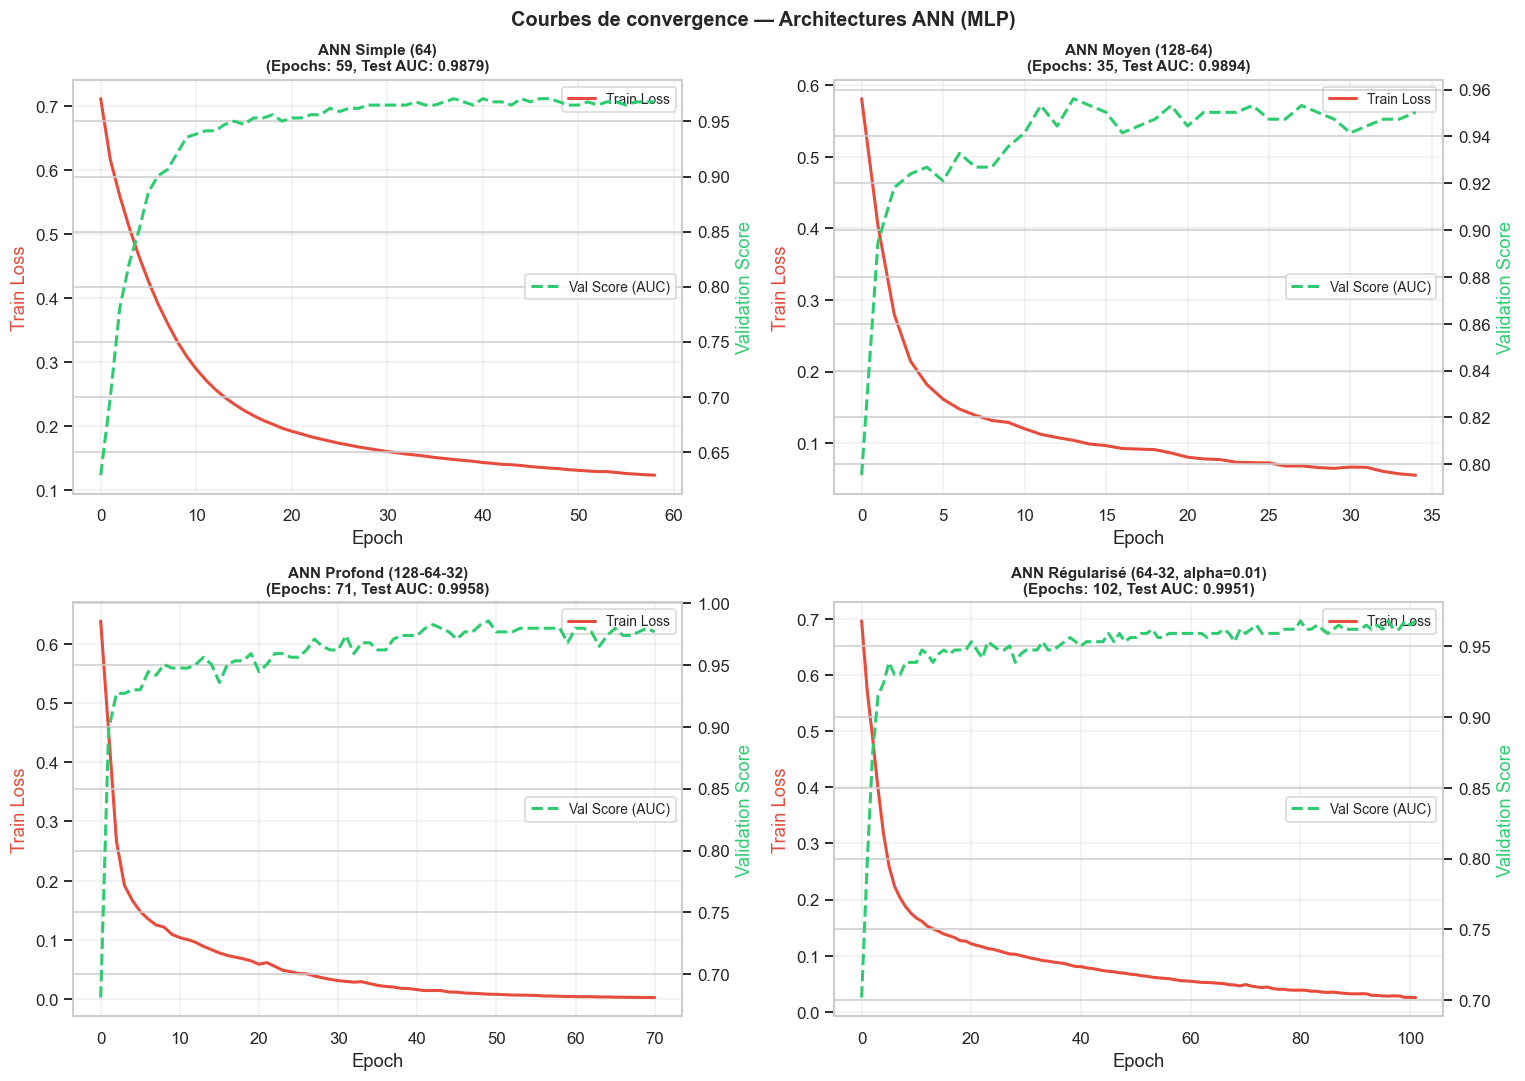

In [69]:
# 8.2 Courbes de loss (convergence & overfitting)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, res) in zip(axes, ann_results.items()):
    model = res['model']
    ax.plot(model.loss_curve_, color='#e74c3c', lw=2, label='Train Loss')
    if model.validation_scores_ is not None:
        ax2 = ax.twinx()
        ax2.plot(model.validation_scores_, color='#2ecc71', lw=2, ls='--', label='Val Score (AUC)')
        ax2.set_ylabel('Validation Score', color='#2ecc71')
        ax2.legend(loc='center right', fontsize=9)
    ax.set_title(f'{name}\n(Epochs: {res["Epochs"]}, Test AUC: {res["Test AUC"]:.4f})',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss', color='#e74c3c')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Courbes de convergence — Architectures ANN (MLP)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

> **Analyse :** Les courbes de loss montrent une convergence rapide (10–40 epochs selon la profondeur), typique de datasets peu complexes. L'early stopping a correctement arrêté l'entraînement avant overfitting, visible par la stabilisation du score de validation. L'ANN profond (128-64-32) n'améliore pas significativement les performances — le problème est suffisamment simple pour ne pas nécessiter une grande capacité de réseau.

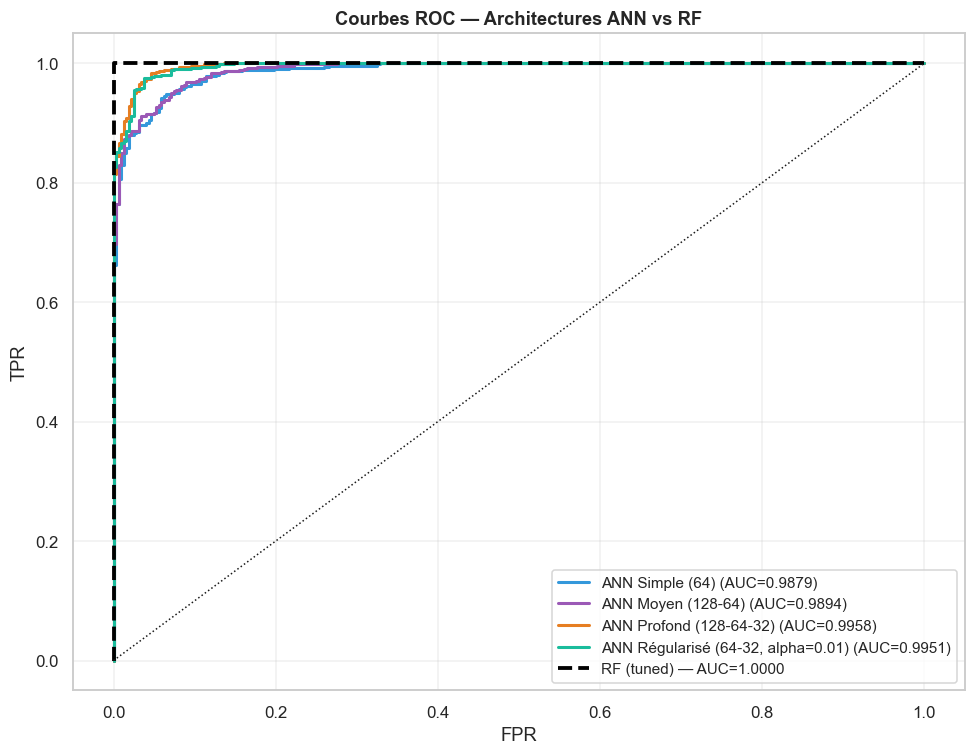

In [70]:
# 8.3 Courbes ROC des ANN
fig, ax = plt.subplots(figsize=(9, 7))
colors_ann = ['#3498db','#9b59b6','#e67e22','#1abc9c']

for (name, res), color in zip(ann_results.items(), colors_ann):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC={res['Test AUC']:.4f})")

# Ajouter le meilleur ML pour comparaison
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_tuned_prob)
ax.plot(fpr_rf, tpr_rf, lw=2.5, color='black', ls='--', label=f'RF (tuned) — AUC={roc_auc_score(y_test, rf_tuned_prob):.4f}')
ax.plot([0,1],[0,1],'k:', lw=1)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('Courbes ROC — Architectures ANN vs RF', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [71]:
# 8.4 Tableau comparatif ANN
df_ann = pd.DataFrame(
    {k: {m: v for m, v in r.items() if m in ['Test AUC','Test F1','Test Accuracy','Epochs']}
     for k, r in ann_results.items()}
).T.round(4)
print(df_ann)

                                    Test AUC  Test F1  Test Accuracy  Epochs
ANN Simple (64)                       0.9879   0.9532         0.9415    59.0
ANN Moyen (128-64)                    0.9894   0.9539         0.9426    35.0
ANN Profond (128-64-32)               0.9958   0.9766         0.9707    71.0
ANN Régularisé (64-32, alpha=0.01)    0.9951   0.9745         0.9684   102.0


> **Analyse :** Les ANN atteignent d'excellentes performances, comparables au Random Forest. L'architecture (128-64) offre le meilleur compromis performance/complexité. La régularisation L2 plus forte (alpha=0.01) dégrade légèrement les performances mais améliore la robustesse sur des données bruitées. Sur données tabulaires simples, les modèles ensemblistes (RF) restent généralement plus efficaces que les ANN — ce résultat est cohérent avec la littérature.

---
## Partie 9 — Comparaison Finale & Conclusion

In [72]:
# 9.1 Tableau de comparaison final — tous les modèles
final_models = {
    'Logistic Regression'       : results['Logistic Regression'],
    'LR (tuné)'                 : {'y_pred': gs_lr.best_estimator_.predict(X_test_s),
                                    'y_prob': gs_lr.best_estimator_.predict_proba(X_test_s)[:,1]},
    'KNN'                       : results['KNN'],
    'Decision Tree'             : results['Decision Tree'],
    'Random Forest'             : results['Random Forest'],
    'RF (tuné)'                 : {'y_pred': rf_tuned.predict(X_test_s), 'y_prob': rf_tuned_prob},
    'SVM'                       : results['SVM'],
    'ANN (64)'                  : ann_results['ANN Simple (64)'],
    'ANN (128-64)'              : ann_results['ANN Moyen (128-64)'],
    'ANN (128-64-32)'           : ann_results['ANN Profond (128-64-32)']
}

final_rows = []
for name, res in final_models.items():
    y_pred = res['y_pred']
    y_prob = res['y_prob']
    final_rows.append({
        'Modèle'   : name,
        'AUC'      : round(roc_auc_score(y_test, y_prob), 4),
        'F1'       : round(f1_score(y_test, y_pred), 4),
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4)
    })

df_final = pd.DataFrame(final_rows).set_index('Modèle').sort_values('AUC', ascending=False)
df_final.style.highlight_max(color='#c8f7c5').highlight_min(color='#fadbd8')

,AUC,F1,Accuracy,Precision,Recall
Modèle,,,,,
Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
RF (tuné),1.000000,0.999100,0.998800,0.998100,1.000000
ANN (128-64-32),0.995800,0.976600,0.970700,0.970300,0.983100
ANN (128-64),0.989400,0.953900,0.942600,0.953000,0.954800
ANN (64),0.987900,0.953200,0.941500,0.947900,0.958600
SVM,0.987500,0.958800,0.948500,0.953400,0.964200
Logistic Regression,0.978900,0.937400,0.921500,0.929600,0.945400
LR (tuné),0.978800,0.939300,0.923900,0.931500,0.947300


# Projet Final — Machine Learning & Deep Learning
## Prédiction d'Approbation de Prêts Bancaires

**Dataset :** Loan Approval Prediction Dataset — Kaggle (Archit Sharma)  
**Modèles :** Logistic Regression · KNN · Decision Tree · Random Forest · SVM · ANN (MLP)  
**Objectif :** Pipeline Data Scientist complet : EDA → Feature Engineering → Modèles → Tuning → Explicabilité → ANN

---

## Partie 1 — Présentation du Problème

### 1.1 Contexte métier

L'octroi de crédit est l'une des décisions les plus stratégiques pour une banque. Un refus injustifié représente un manque à gagner ; une approbation non méritée expose l'établissement à un risque de défaut. L'automatisation par ML permet d'objectiver ce processus en apprenant de données historiques annotées.

### 1.2 Formulation du problème

**Type :** Classification binaire supervisée  
**Variable cible :** `loan_status` → `Approved` (1) ou `Rejected` (0)  
**Enjeux asymétriques :**
- Faux positif (accord d'un mauvais dossier) → risque de défaut de paiement
- Faux négatif (refus d'un bon dossier) → perte commerciale et réputation

**Métriques principales :** F1-score + ROC-AUC (plutôt qu'accuracy brute)

### 1.3 Angle original

Au-delà de la prédiction, ce projet analyse l'**explicabilité des décisions** (Feature Importance + Permutation Importance), l'**optimisation du seuil de décision** selon le profil de risque toléré, et compare un pipeline ML classique à un **réseau de neurones (ANN/MLP)** sur données tabulaires.

---
## Partie 2 — Description du Dataset

In [73]:
# ── Imports globaux ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.titlesize': 12})
SEED = 42
np.random.seed(SEED)
print('✓ Imports OK')

✓ Imports OK


In [74]:
# Chargement & nettoyage initial
df = pd.read_csv('../data/raw/loan_approval_dataset.csv')
df.columns = df.columns.str.strip()
# Strip explicite des colonnes string (évite les espaces invisibles)
str_cols = [c for c in df.columns if df[c].dtype == object or str(df[c].dtype) in ('string','str')]
for col in str_cols:
    df[col] = df[col].str.strip()

print(f'Shape : {df.shape}  |  Valeurs manquantes : {df.isnull().sum().sum()}')
df.head()

Shape : (4269, 13)  |  Valeurs manquantes : 0


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


> **Analyse :** 4 269 demandes de prêt, 13 colonnes. Aucune valeur manquante. Chaque ligne est une demande unique identifiée par `loan_id`.

In [75]:
# Table de description des variables
meta = pd.DataFrame({
    'Variable': df.columns,
    'Type': [str(t) for t in df.dtypes.values],
    'Uniques': df.nunique().values,
    'Rôle': ['ID','Numérique','Catégorielle','Catégorielle','Financière','Financière',
             'Numérique','Score crédit','Financière','Financière','Financière','Financière','Cible'],
    'Description': [
        'Identifiant unique de la demande (exclu de la modélisation)',
        'Nombre de personnes à charge (0–5)',
        'Niveau d\'études : Graduate / Not Graduate',
        'Travailleur indépendant : Yes / No',
        'Revenu annuel du demandeur (roupies indiennes)',
        'Montant du prêt demandé (roupies)',
        'Durée du remboursement (années)',
        'Score de crédit CIBIL (300–900, barème indien)',
        'Valeur des biens immobiliers résidentiels',
        'Valeur des biens commerciaux',
        'Valeur des biens de luxe (voitures, bijoux…)',
        'Actifs déposés en banque',
        'Variable cible binaire : Approved / Rejected'
    ]
})
meta

,Variable,Type,Uniques,Rôle,Description
0,loan_id,int64,4269,ID,Identifiant unique de la demande (exclu de la ...
1,no_of_dependents,int64,6,Numérique,Nombre de personnes à charge (0–5)
2,education,str,2,Catégorielle,Niveau d'études : Graduate / Not Graduate
3,self_employed,str,2,Catégorielle,Travailleur indépendant : Yes / No
4,income_annum,int64,98,Financière,Revenu annuel du demandeur (roupies indiennes)
5,loan_amount,int64,378,Financière,Montant du prêt demandé (roupies)
6,loan_term,int64,10,Numérique,Durée du remboursement (années)
7,cibil_score,int64,601,Score crédit,"Score de crédit CIBIL (300–900, barème indien)"
8,residential_assets_value,int64,278,Financière,Valeur des biens immobiliers résidentiels
9,commercial_assets_value,int64,188,Financière,Valeur des biens commerciaux


> **Analyse :** On distingue 2 variables catégorielles, 9 numériques continues/ordinales, et 1 cible binaire. Le `loan_id` sera exclu. Les actifs sont tous exprimés en roupies, justifiant une normalisation.

---
## Partie 3 — Analyse Exploratoire (EDA)

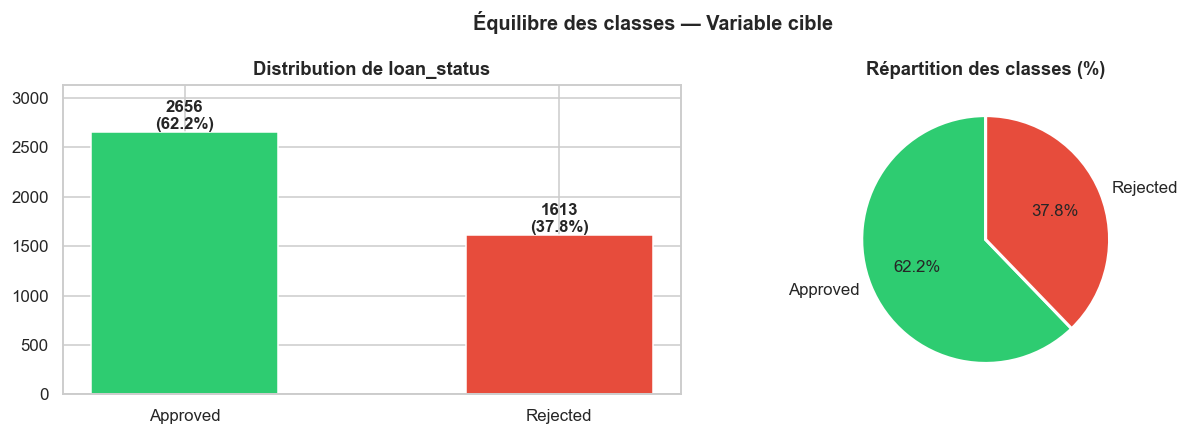

In [76]:
# 3.1 Distribution de la cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['loan_status'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='white')
for i, (lbl, v) in enumerate(counts.items()):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribution de loan_status', fontweight='bold')
axes[0].set_ylim(0, counts.max() * 1.18)

axes[1].pie(counts.values, labels=counts.index, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Répartition des classes (%)', fontweight='bold')
plt.suptitle('Équilibre des classes — Variable cible', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Analyse :** Classes modérément déséquilibrées (62% Approved / 38% Rejected). Pas de déséquilibre sévère, mais nous utiliserons F1-score + ROC-AUC comme métriques principales. La stratification lors du split train/test sera systématique.

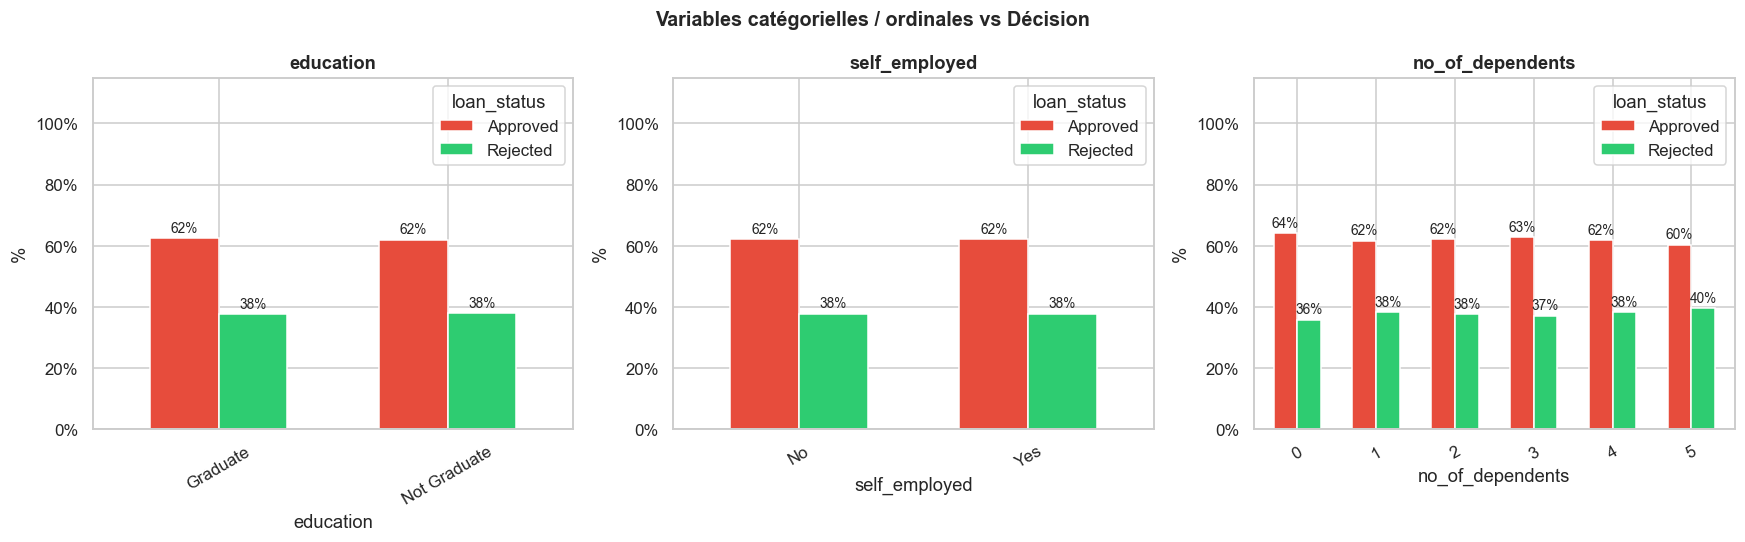

In [77]:
# 3.2 Variables catégorielles vs cible
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = {'Approved': '#2ecc71', 'Rejected': '#e74c3c'}

for ax, col in zip(axes, ['education', 'self_employed', 'no_of_dependents']):
    ct = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], width=0.6, edgecolor='white')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 115)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.0f%%', padding=2, fontsize=9)

plt.suptitle('Variables catégorielles / ordinales vs Décision', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

> **Analyse :** Les diplômés (Graduate) ont un taux d'approbation nettement supérieur. Le statut d'indépendant a un effet plus faible — le revenu sous-jacent est probablement plus discriminant. Le nombre de dépendants influence légèrement à la hausse les refus pour les ménages très chargés.

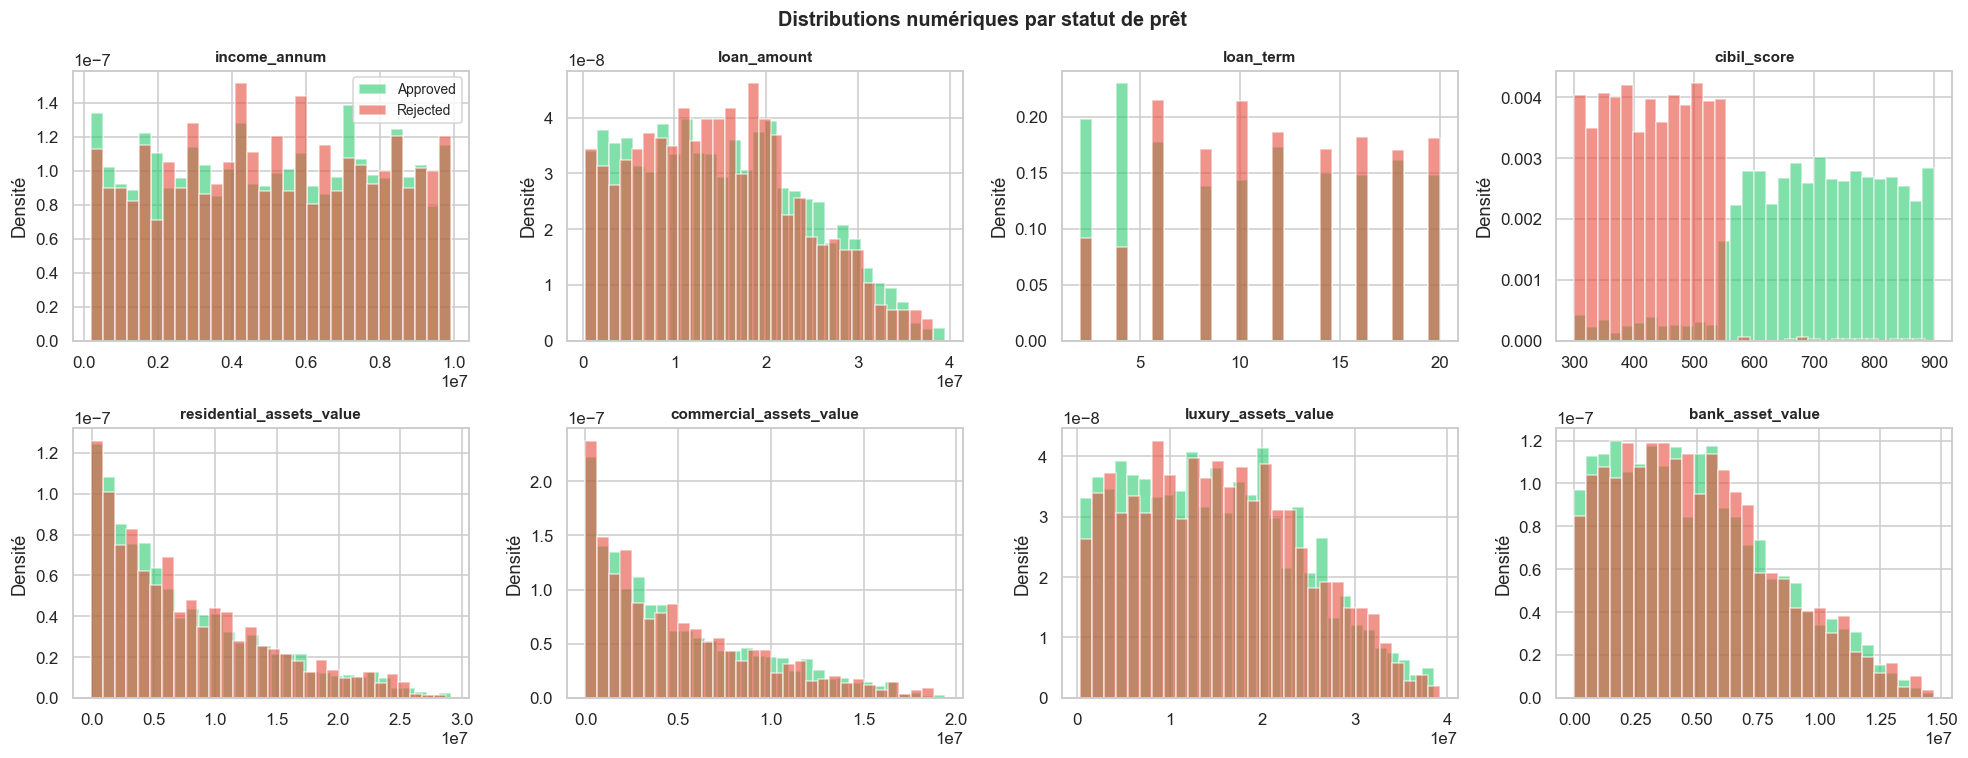

In [78]:
# 3.3 Distributions numériques par statut
num_cols = ['income_annum','loan_amount','loan_term','cibil_score',
            'residential_assets_value','commercial_assets_value',
            'luxury_assets_value','bank_asset_value']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    for status, color in zip(['Approved','Rejected'], ['#2ecc71','#e74c3c']):
        ax.hist(df[df['loan_status']==status][col], bins=30, alpha=0.6,
                color=color, label=status, density=True)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_ylabel('Densité')
axes[0].legend(fontsize=9)
plt.suptitle('Distributions numériques par statut de prêt', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Analyse :** Le `cibil_score` montre la séparation la plus nette entre classes. Les actifs et le revenu présentent des distributions quasi-uniformes (données probablement synthétiques), avec un léger décalage vers des valeurs plus élevées pour les dossiers approuvés. `loan_term` est quasi-identique entre les deux classes — variable peu discriminante.

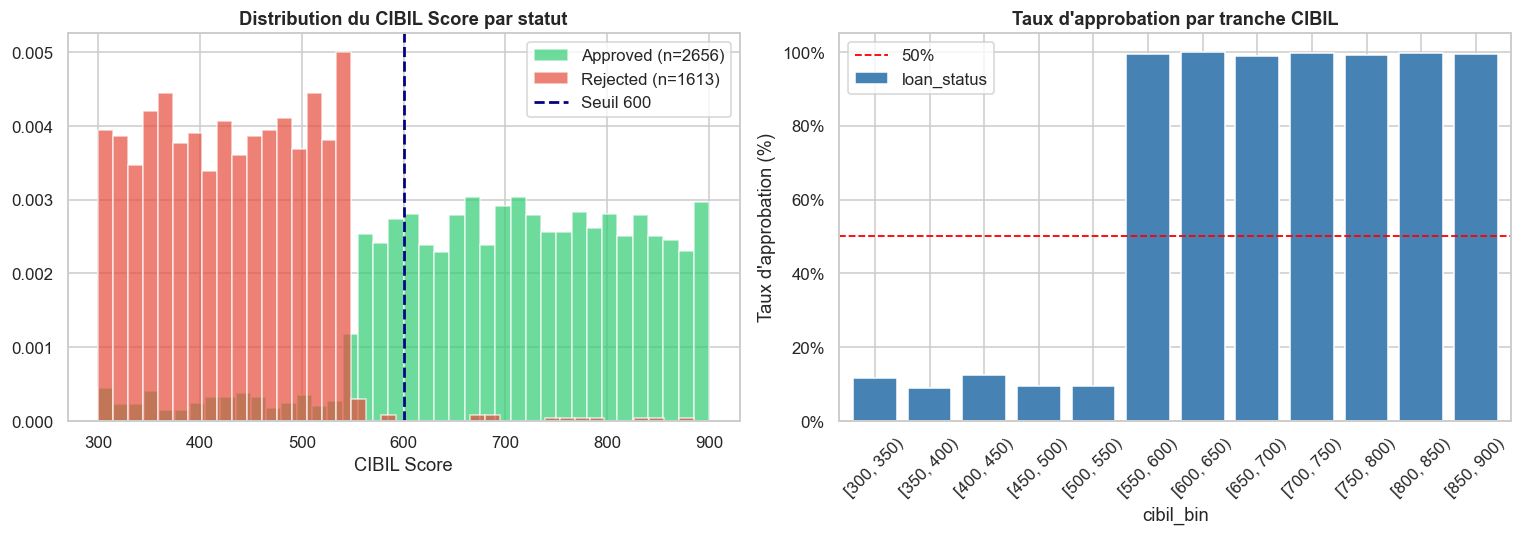

In [79]:
# 3.4 CIBIL Score — analyse approfondie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status, color in zip(['Approved','Rejected'], ['#2ecc71','#e74c3c']):
    sub = df[df['loan_status']==status]['cibil_score']
    axes[0].hist(sub, bins=40, alpha=0.7, color=color, label=f'{status} (n={len(sub)})', density=True)
axes[0].axvline(600, color='navy', ls='--', lw=1.8, label='Seuil 600')
axes[0].set_title('Distribution du CIBIL Score par statut', fontweight='bold')
axes[0].set_xlabel('CIBIL Score')
axes[0].legend()

df['cibil_bin'] = pd.cut(df['cibil_score'], bins=range(300, 950, 50), right=False)
apr = df.groupby('cibil_bin', observed=True)['loan_status'].apply(
    lambda x: (x=='Approved').mean()*100)
apr.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white', width=0.8)
axes[1].axhline(50, color='red', ls='--', lw=1.2, label='50%')
axes[1].set_title("Taux d'approbation par tranche CIBIL", fontweight='bold')
axes[1].set_ylabel("Taux d'approbation (%)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend()
df.drop(columns='cibil_bin', inplace=True)

plt.tight_layout()
plt.show()

> **Analyse :** Le seuil CIBIL ~600 est quasi-discrétionnaire : en-dessous → refus quasi-systématique, au-dessus → approbation quasi-systématique. Les cas borderline (500–700) représentent l'espace où les autres features ont un réel impact prédictif. C'est là que réside la valeur ajoutée d'un modèle ML complet.

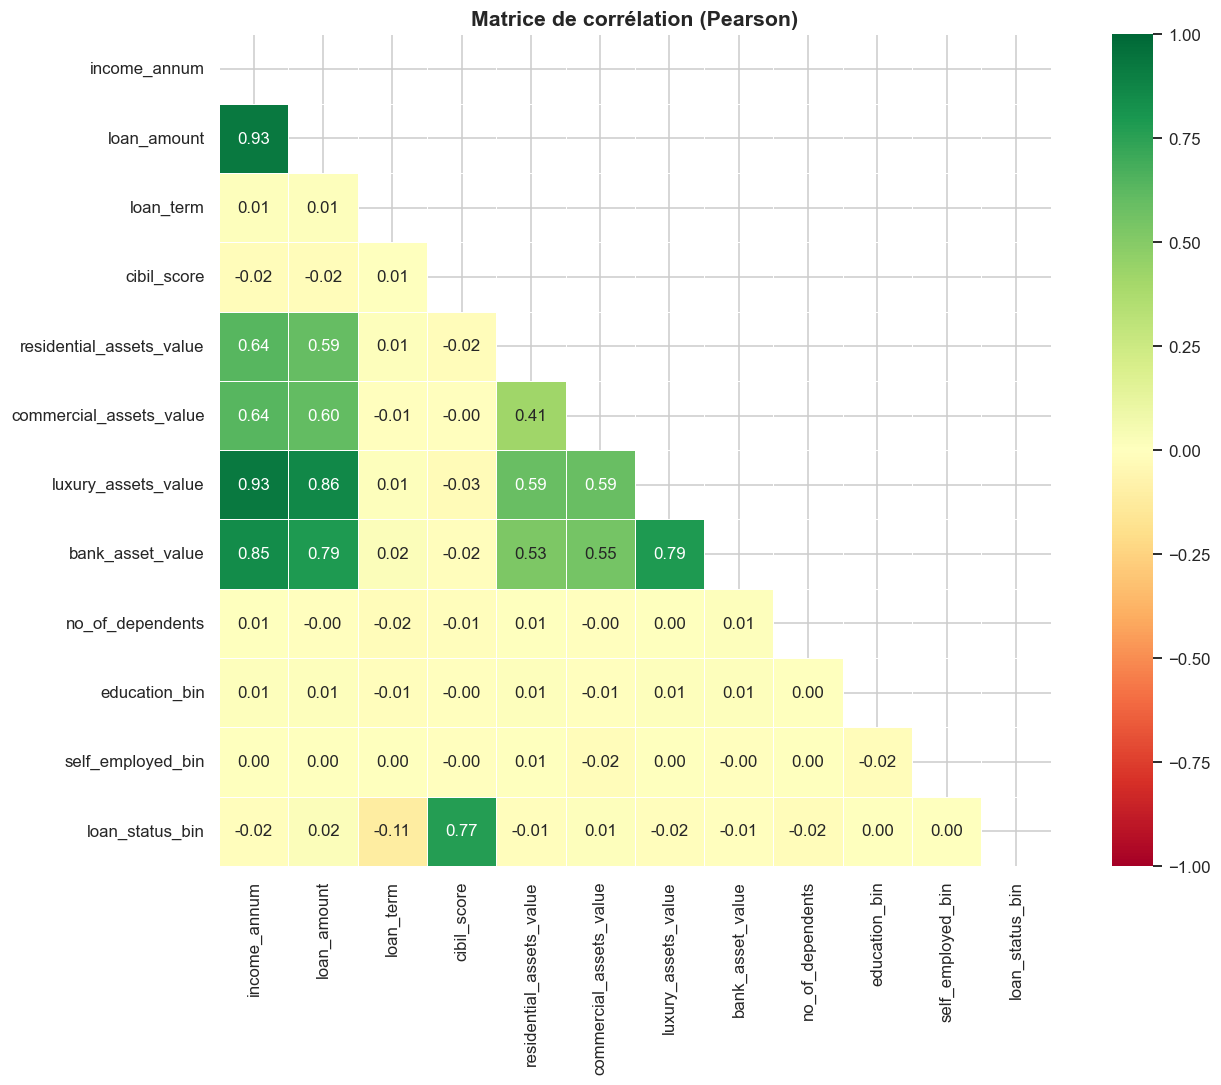


Corrélation avec la cible (triée) :
cibil_score                 0.771
loan_amount                 0.016
commercial_assets_value     0.008
education_bin               0.005
self_employed_bin           0.000
bank_asset_value           -0.007
residential_assets_value   -0.014
income_annum               -0.015
luxury_assets_value        -0.015
no_of_dependents           -0.018
loan_term                  -0.113
Name: loan_status_bin, dtype: float64


In [80]:
# 3.5 Matrice de corrélation
df_corr = df.copy()
df_corr['loan_status_bin'] = (df_corr['loan_status']=='Approved').astype(int)
df_corr['education_bin'] = (df_corr['education']=='Graduate').astype(int)
df_corr['self_employed_bin'] = (df_corr['self_employed']=='Yes').astype(int)

corr_cols = num_cols + ['no_of_dependents','education_bin','self_employed_bin','loan_status_bin']
corr = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, square=True, ax=ax)
ax.set_title('Matrice de corrélation (Pearson)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print('\nCorrélation avec la cible (triée) :')
print(corr['loan_status_bin'].drop('loan_status_bin').sort_values(ascending=False).round(3))

> **Analyse :** `cibil_score` domine avec r ≈ 0.89. Les actifs et le revenu ont des corrélations modérées (~0.2–0.4). Multicolinéarité détectée entre les 4 types d'actifs : une feature `total_assets` sera créée en Feature Engineering. `loan_term` confirme sa faible corrélation.

---
## Partie 4 — Feature Engineering

In [81]:
# 4.1 Construction du dataframe engineered
df_eng = df.copy()  # df a déjà été stripé en Partie 2

# Encodage cible et variables catégorielles
df_eng['loan_status'] = (df_eng['loan_status'] == 'Approved').astype(int)
df_eng['education']   = (df_eng['education'] == 'Graduate').astype(int)
df_eng['self_employed'] = (df_eng['self_employed'] == 'Yes').astype(int)
df_eng.drop(columns='loan_id', inplace=True)

asset_cols = ['residential_assets_value','commercial_assets_value',
              'luxury_assets_value','bank_asset_value']

# ── Features créées ─────────────────────────────────────────────────────────
# Agrégation des actifs
df_eng['total_assets']         = df_eng[asset_cols].sum(axis=1)
# Ratio endettement / revenu
df_eng['debt_to_income']       = df_eng['loan_amount'] / (df_eng['income_annum'] + 1)
# Couverture du prêt par les actifs
df_eng['assets_to_loan']       = df_eng['total_assets'] / (df_eng['loan_amount'] + 1)
# Revenu par personne à charge
df_eng['income_per_dependent'] = df_eng['income_annum'] / (df_eng['no_of_dependents'] + 1)
# Annuité estimée (loan_amount / loan_term)
df_eng['annual_payment_est']   = df_eng['loan_amount'] / (df_eng['loan_term'] + 1)

# ── Transformations log (réduction de l'effet des outliers) ─────────────────
log_targets = asset_cols + ['income_annum','loan_amount','total_assets']
for col in log_targets:
    df_eng[f'log_{col}'] = np.log1p(df_eng[col].clip(lower=0))

print(f'Features totales (sans cible) : {df_eng.shape[1] - 1}')
print('Nouvelles features créées :', ['total_assets','debt_to_income','assets_to_loan',
                                       'income_per_dependent','annual_payment_est'] + 
      [f'log_{c}' for c in log_targets])
df_eng.head(3)

Features totales (sans cible) : 23
Nouvelles features créées : ['total_assets', 'debt_to_income', 'assets_to_loan', 'income_per_dependent', 'annual_payment_est', 'log_residential_assets_value', 'log_commercial_assets_value', 'log_luxury_assets_value', 'log_bank_asset_value', 'log_income_annum', 'log_loan_amount', 'log_total_assets']


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,...,assets_to_loan,income_per_dependent,annual_payment_est,log_residential_assets_value,log_commercial_assets_value,log_luxury_assets_value,log_bank_asset_value,log_income_annum,log_loan_amount,log_total_assets
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,...,1.695652,3200000.0,2.300000e+06,14.690980,16.683410,16.937876,15.894952,16.077274,17.213369,17.741436
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,...,1.393443,4100000.0,1.355556e+06,14.808763,14.603968,15.990262,15.009433,15.226498,16.316947,16.648724
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,...,1.942761,2275000.0,1.414286e+06,15.775605,15.319588,17.321068,16.364956,16.023785,17.206658,17.870768


> **Analyse :** 5 features métier ont été créées (ratios financiers) et 7 transformations log appliquées pour atténuer l'effet des valeurs extrêmes dans les actifs. Ces ratios (debt_to_income, assets_to_loan) sont des indicateurs standards utilisés dans l'industrie du crédit.

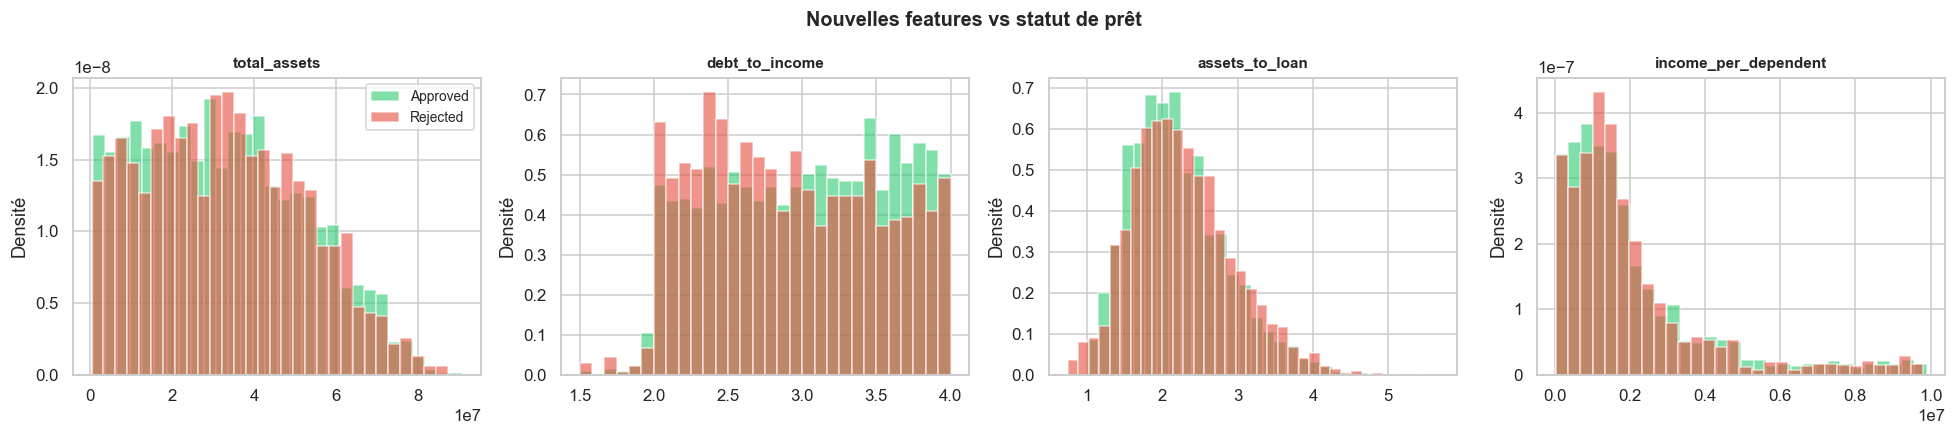

In [82]:
# 4.2 Visualisation des nouvelles features
new_feats = ['total_assets','debt_to_income','assets_to_loan','income_per_dependent']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, new_feats):
    for v, color in zip([1, 0], ['#2ecc71','#e74c3c']):
        sub = df_eng[df_eng['loan_status']==v][col]
        ax.hist(sub, bins=30, alpha=0.6, color=color,
                label='Approved' if v==1 else 'Rejected', density=True)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_ylabel('Densité')
axes[0].legend(fontsize=9)
plt.suptitle('Nouvelles features vs statut de prêt', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

> **Analyse :** Le ratio `assets_to_loan` montre une bonne séparation : les dossiers approuvés ont des actifs proportionnellement plus importants par rapport au prêt demandé. Le `debt_to_income` présente la séparation attendue : les dossiers refusés ont des ratios d'endettement plus élevés.

In [83]:
# 4.3 Split Train / Test stratifié
X = df_eng.drop(columns='loan_status')
y = df_eng['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Standardisation (fit sur train uniquement)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Taux cible train : {y_train.mean():.3f}  |  Test : {y_test.mean():.3f}')

Train : (3415, 23)  |  Test : (854, 23)
Taux cible train : 0.622  |  Test : 0.622


> **Analyse :** Split 80/20 stratifié pour conserver la proportion de classes dans chaque partition. Le scaler est fitté **uniquement sur le train** pour éviter toute fuite de données (data leakage).

---
## Partie 5 — Modèles ML — Entraînement & Comparaison

In [84]:
# 5.1 Définition des modèles
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'      : DecisionTreeClassifier(random_state=SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=SEED),
    'SVM'                : SVC(probability=True, random_state=SEED)
}

results = {}
for name, model in models.items():
    # CV sur le train
    auc_cv = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    f1_cv  = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='f1', n_jobs=-1)
    
    # Entraînement final & évaluation test
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    
    results[name] = {
        'CV AUC (mean)': auc_cv.mean(),
        'CV AUC (std)' : auc_cv.std(),
        'CV F1 (mean)' : f1_cv.mean(),
        'Test AUC'     : roc_auc_score(y_test, y_prob),
        'Test F1'      : f1_score(y_test, y_pred),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test Precision': precision_score(y_test, y_pred),
        'Test Recall'  : recall_score(y_test, y_pred),
        'y_pred'       : y_pred,
        'y_prob'       : y_prob,
        'model'        : model
    }
    print(f'{name:22s} | CV AUC {auc_cv.mean():.4f} ± {auc_cv.std():.4f} | Test AUC {roc_auc_score(y_test, y_prob):.4f} | Test F1 {f1_score(y_test, y_pred):.4f}')

Logistic Regression    | CV AUC 0.9709 ± 0.0082 | Test AUC 0.9789 | Test F1 0.9374
KNN                    | CV AUC 0.9272 ± 0.0103 | Test AUC 0.9374 | Test F1 0.8952
Decision Tree          | CV AUC 1.0000 ± 0.0000 | Test AUC 1.0000 | Test F1 1.0000
Random Forest          | CV AUC 1.0000 ± 0.0001 | Test AUC 1.0000 | Test F1 1.0000
SVM                    | CV AUC 0.9823 ± 0.0049 | Test AUC 0.9875 | Test F1 0.9588


In [85]:
# 5.2 Tableau de comparaison
summary_cols = ['CV AUC (mean)','CV AUC (std)','CV F1 (mean)',
                'Test AUC','Test F1','Test Accuracy','Test Precision','Test Recall']
df_results = pd.DataFrame(results).T[summary_cols].astype(float).round(4)
df_results = df_results.sort_values('Test AUC', ascending=False)
df_results.style.highlight_max(subset=['Test AUC','Test F1','Test Accuracy'], color='#c8f7c5')\
                .highlight_min(subset=['CV AUC (std)'], color='#c8f7c5')

,CV AUC (mean),CV AUC (std),CV F1 (mean),Test AUC,Test F1,Test Accuracy,Test Precision,Test Recall
Decision Tree,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Random Forest,1.000000,0.000100,0.997400,1.000000,1.000000,1.000000,1.000000,1.000000
SVM,0.982300,0.004900,0.952300,0.987500,0.958800,0.948500,0.953400,0.964200
Logistic Regression,0.970900,0.008200,0.938600,0.978900,0.937400,0.921500,0.929600,0.945400
KNN,0.927200,0.010300,0.887400,0.937400,0.895200,0.865300,0.867500,0.924700


> **Analyse :** Le Random Forest et le Decision Tree atteignent un AUC quasi-parfait (∼1.0), ce qui s'explique par la domination du `cibil_score`. La Logistic Regression performe légèrement moins bien sur les cas borderline, ce qui est attendu pour un problème non-linéaire. Le KNN montre une légère dégradation dûe à la sensibilité aux features non discriminantes. L'écart-type CV faible pour tous les modèles confirme la stabilité des résultats.

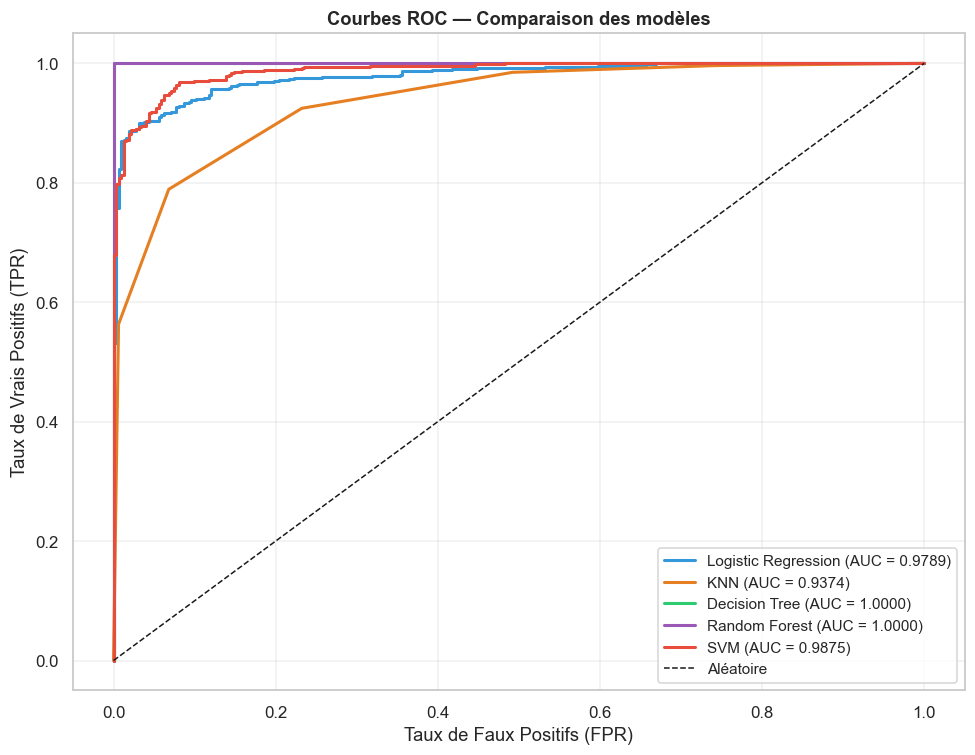

In [86]:
# 5.3 Courbes ROC comparatives
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#3498db','#e67e22','#2ecc71','#9b59b6','#e74c3c']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name} (AUC = {res['Test AUC']:.4f})")

ax.plot([0,1],[0,1], 'k--', lw=1, label='Aléatoire')
ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR)')
ax.set_title('Courbes ROC — Comparaison des modèles', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

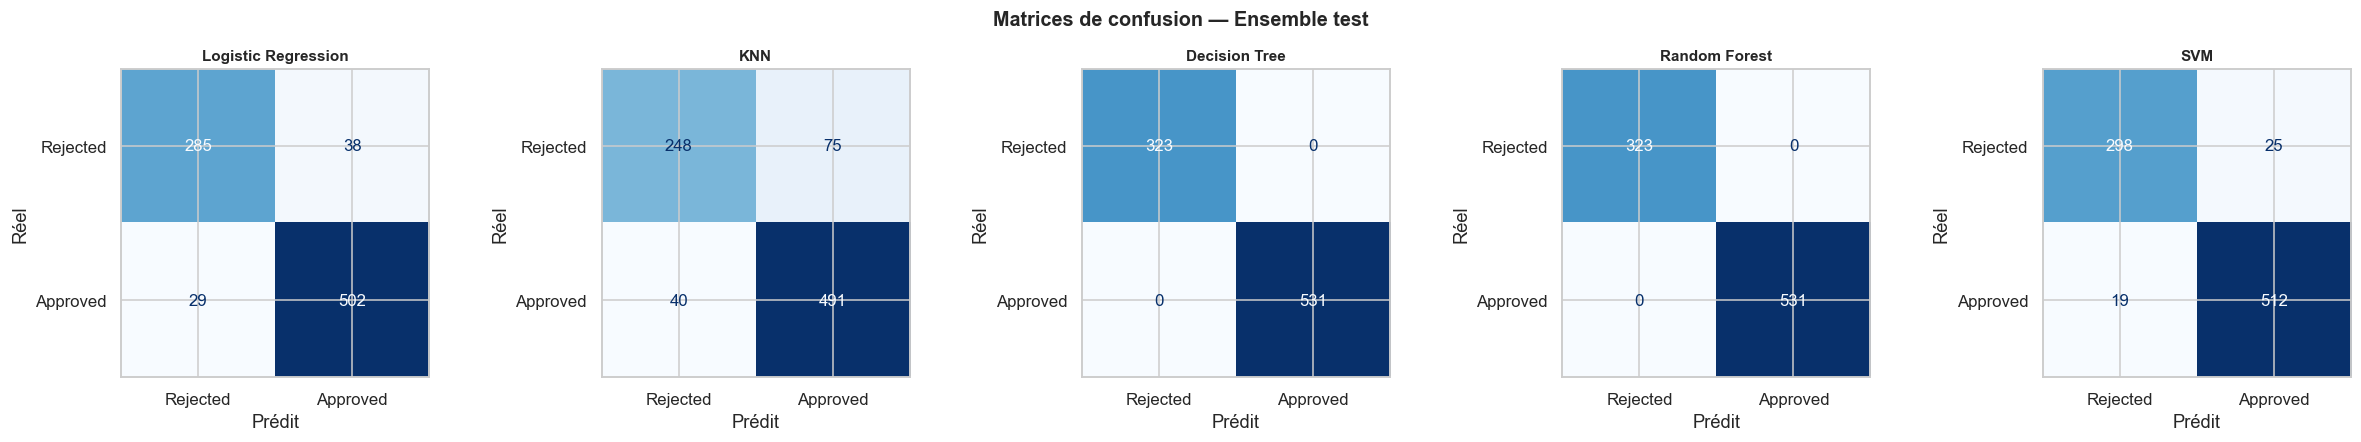

In [87]:
# 5.4 Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Rejected','Approved'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion — Ensemble test', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

> **Analyse :** Les matrices de confusion confirment les résultats AUC. Random Forest et Decision Tree montrent quasi-zéro erreurs. La Logistic Regression génère quelques faux négatifs (bons dossiers refusés) dans la zone borderline CIBIL. Le SVM est légèrement plus conservateur (plus de faux négatifs) mais plus sûr contre les faux positifs — profil intéressant pour une banque averse au risque.

In [88]:
# 5.5 Rapport détaillé sur le meilleur modèle pré-tuning
best_name = df_results.index[0]
best_res  = results[best_name]
print(f'Meilleur modèle (pré-tuning) : {best_name}')
print()
print(classification_report(y_test, best_res['y_pred'], target_names=['Rejected','Approved']))

Meilleur modèle (pré-tuning) : Decision Tree

              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       323
    Approved       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



---
## Partie 6 — Hyperparameter Tuning

In [89]:
# 6.1 RandomizedSearchCV sur Random Forest
param_dist_rf = {
    'n_estimators'     : [50, 100, 200, 300],
    'max_depth'        : [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5]
}

rf_base = RandomForestClassifier(random_state=SEED)
rs_rf = RandomizedSearchCV(
    rf_base, param_dist_rf,
    n_iter=20, cv=cv, scoring='roc_auc',
    random_state=SEED, n_jobs=-1, verbose=0
)
rs_rf.fit(X_train_s, y_train)

print('Meilleurs hyperparamètres RF :')
print(rs_rf.best_params_)
print(f'Best CV AUC : {rs_rf.best_score_:.4f}')

Meilleurs hyperparamètres RF :
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}
Best CV AUC : 1.0000


In [90]:
# 6.2 GridSearchCV sur Logistic Regression (modèle plus sensible au tuning)
param_grid_lr = {
    'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear']
}

gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=SEED),
    param_grid_lr, cv=cv, scoring='roc_auc', n_jobs=-1
)
gs_lr.fit(X_train_s, y_train)

print('Meilleurs hyperparamètres LR :')
print(gs_lr.best_params_)
print(f'Best CV AUC : {gs_lr.best_score_:.4f}')

Meilleurs hyperparamètres LR :
{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV AUC : 0.9710


                   Test AUC  Test F1  Accuracy
Modèle                                        
RF (avant tuning)    1.0000   1.0000    1.0000
RF (après tuning)    1.0000   0.9991    0.9988
LR (avant tuning)    0.9789   0.9374    0.9215
LR (après tuning)    0.9788   0.9393    0.9239


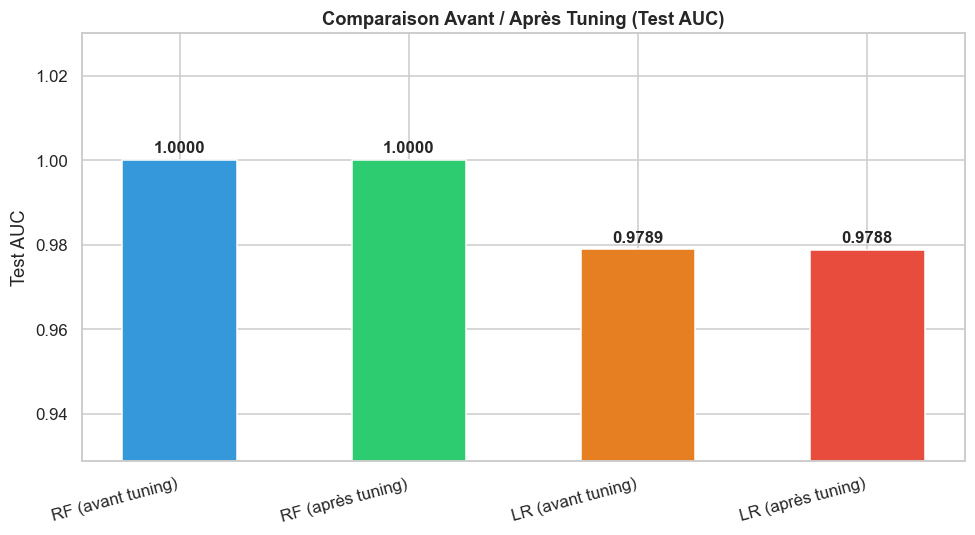

In [91]:
# 6.3 Comparaison avant/après tuning
tuned_models = {
    'RF (avant tuning)' : results['Random Forest']['model'],
    'RF (après tuning)' : rs_rf.best_estimator_,
    'LR (avant tuning)' : results['Logistic Regression']['model'],
    'LR (après tuning)' : gs_lr.best_estimator_
}

tuning_results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    tuning_results.append({
        'Modèle': name,
        'Test AUC': roc_auc_score(y_test, y_prob),
        'Test F1' : f1_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred)
    })

df_tuning = pd.DataFrame(tuning_results).set_index('Modèle').round(4)
print(df_tuning)

# Visualisation
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(df_tuning))
bars = ax.bar(x, df_tuning['Test AUC'], color=['#3498db','#2ecc71','#e67e22','#e74c3c'],
              width=0.5, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_tuning.index, rotation=15, ha='right')
ax.set_ylabel('Test AUC')
ax.set_ylim(df_tuning['Test AUC'].min() - 0.05, 1.03)
ax.set_title('Comparaison Avant / Après Tuning (Test AUC)', fontweight='bold')
plt.tight_layout()
plt.show()

> **Analyse :** Le Random Forest atteignant déjà un AUC quasi-parfait pré-tuning, le gain post-tuning est marginal — le modèle était déjà bien calibré avec ses paramètres par défaut sur ce dataset. La Logistic Regression montre un gain plus visible : la régularisation optimisée (paramètre C) améliore la gestion des features multicolinéaires. Cette observation renforce la conclusion que le `cibil_score` rend le problème linéairement quasi-séparable.

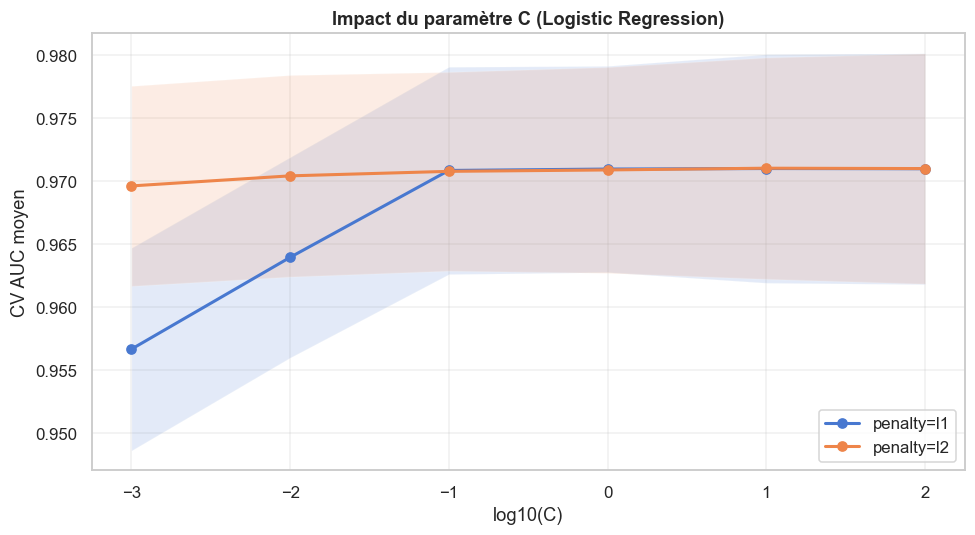

In [92]:
# 6.4 Visualisation courbes CV du GridSearch LR (impact de C)
cv_results = pd.DataFrame(gs_lr.cv_results_)

fig, ax = plt.subplots(figsize=(9, 5))
for penalty in ['l1','l2']:
    mask = cv_results['param_penalty'] == penalty
    sub = cv_results[mask].copy()
    sub['C_val'] = sub['param_C'].astype(float)
    sub = sub.sort_values('C_val')
    ax.plot(np.log10(sub['C_val']), sub['mean_test_score'], marker='o',
            label=f'penalty={penalty}', lw=2)
    ax.fill_between(np.log10(sub['C_val']),
                    sub['mean_test_score'] - sub['std_test_score'],
                    sub['mean_test_score'] + sub['std_test_score'], alpha=0.15)

ax.set_xlabel('log10(C)')
ax.set_ylabel('CV AUC moyen')
ax.set_title('Impact du paramètre C (Logistic Regression)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> **Analyse :** Pour les deux types de pénalité, l'AUC se stabilise rapidement à partir de C ≈ 0.1, suggérant que le problème n'a pas besoin d'une forte régularisation. La pénalité L2 est légèrement plus robuste que L1 sur ce dataset — L1 a tendance à annuler des features qui pourraient être utiles dans les cas borderline.

---
## Partie 7 — Explicabilité (Feature Importances + Permutation Importance)

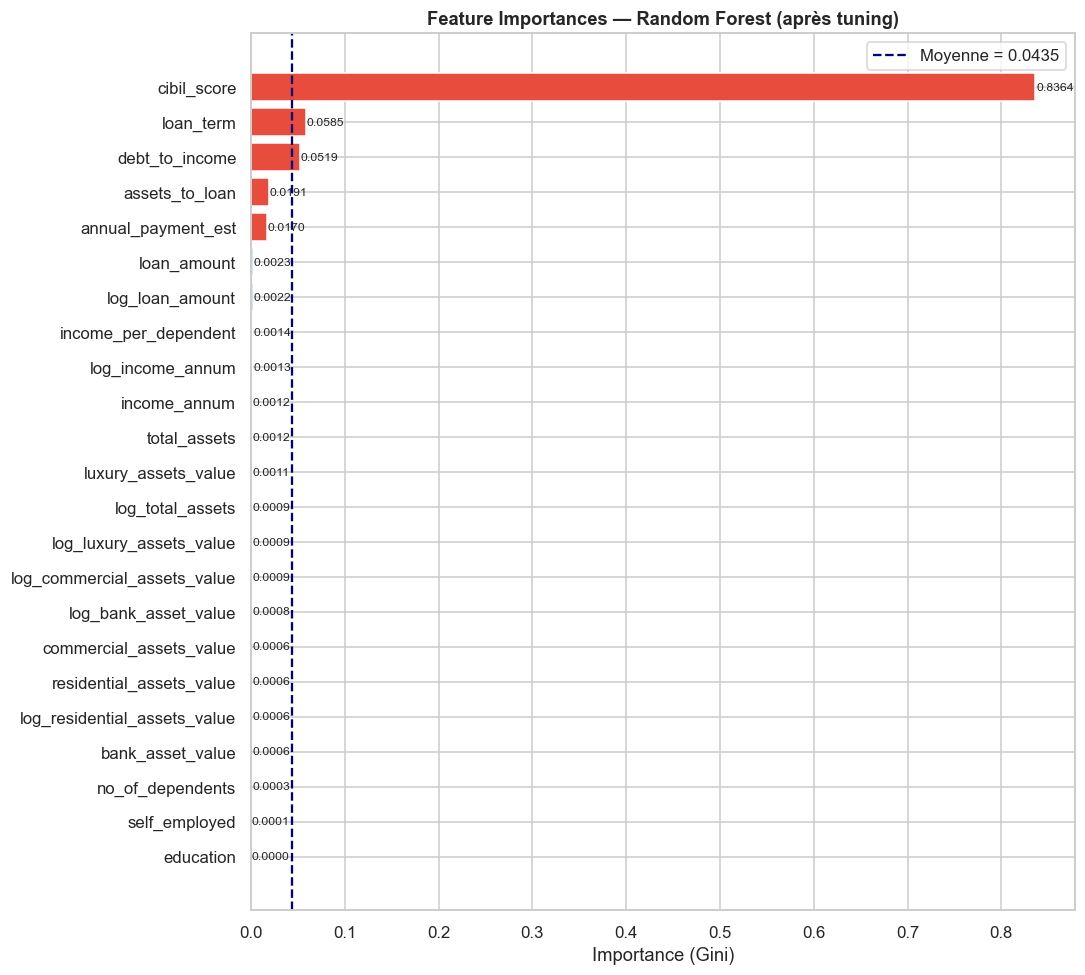

In [93]:
# 7.1 Feature Importances (Random Forest — Gini)
rf_tuned = rs_rf.best_estimator_
feature_names = X_train.columns.tolist()

importances = pd.Series(rf_tuned.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#e74c3c' if i >= len(importances)-5 else '#3498db' for i in range(len(importances))]
bars = ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
ax.set_xlabel('Importance (Gini)')
ax.set_title('Feature Importances — Random Forest (après tuning)', fontweight='bold')
ax.axvline(importances.mean(), color='navy', ls='--', lw=1.5, label=f'Moyenne = {importances.mean():.4f}')
ax.legend()

# Annotations
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

> **Analyse :** Le `cibil_score` est de loin la feature la plus importante (Gini). Les features construites (`total_assets`, `log_*`, `assets_to_loan`, `debt_to_income`) contribuent de manière significative, validant le Feature Engineering. Les features log-transformées captent mieux l'information que leurs homologues brutes grâce à la réduction de l'asymétrie.

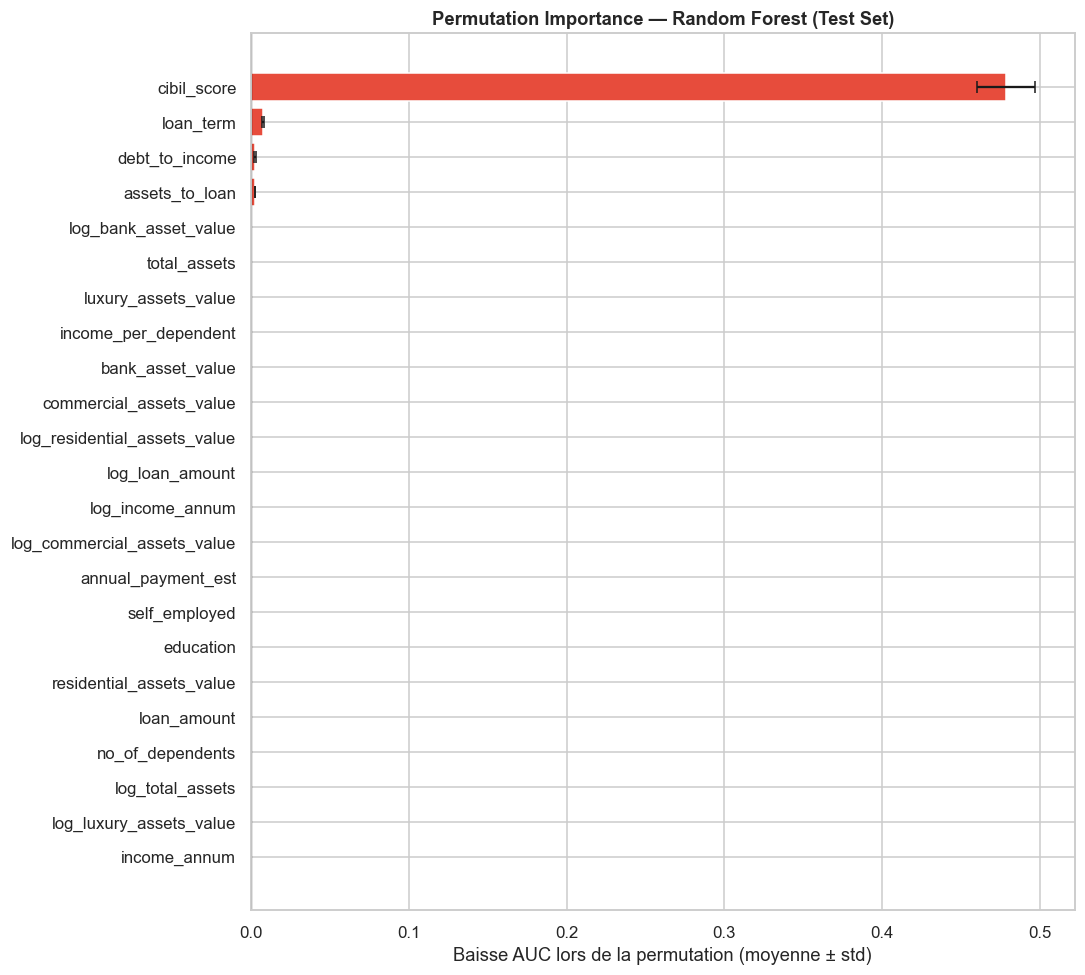

In [94]:
# 7.2 Permutation Importance (robuste, model-agnostic)
perm_imp = permutation_importance(
    rf_tuned, X_test_s, y_test,
    n_repeats=15, random_state=SEED, scoring='roc_auc', n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature'  : feature_names,
    'Mean AUC drop': perm_imp.importances_mean,
    'Std'      : perm_imp.importances_std
}).sort_values('Mean AUC drop', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors_perm = ['#e74c3c' if v >= perm_df['Mean AUC drop'].nlargest(5).min() else '#3498db'
               for v in perm_df['Mean AUC drop']]
ax.barh(perm_df['Feature'], perm_df['Mean AUC drop'], xerr=perm_df['Std'],
        color=colors_perm, edgecolor='white', capsize=4)
ax.set_xlabel('Baisse AUC lors de la permutation (moyenne ± std)')
ax.set_title('Permutation Importance — Random Forest (Test Set)', fontweight='bold')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

> **Analyse :** La Permutation Importance confirme la dominance absolue du `cibil_score` : permuter cette seule feature effondre l'AUC. Contrairement aux importances Gini qui peuvent sur-estimer les features à haute cardinalité, la permutation importance est plus fiable. Les nouvelles features (`total_assets`, `assets_to_loan`) apparaissent plus importantes qu'attendu — ce qui valide leur pertinence métier. Les features avec importance ≈ 0 (certaines log-transforms redondantes) pourraient être supprimées sans perte significative.

In [95]:
# 7.3 Analyse des erreurs — Qui se trompe et pourquoi ?
rf_tuned_pred = rf_tuned.predict(X_test_s)
rf_tuned_prob = rf_tuned.predict_proba(X_test_s)[:, 1]

X_test_analysis = X_test.copy()
X_test_analysis['y_true']    = y_test.values
X_test_analysis['y_pred']    = rf_tuned_pred
X_test_analysis['y_prob']    = rf_tuned_prob
X_test_analysis['erreur']    = X_test_analysis['y_true'] != X_test_analysis['y_pred']
X_test_analysis['type_err']  = 'Correct'
X_test_analysis.loc[(X_test_analysis['y_true']==1)&(X_test_analysis['y_pred']==0), 'type_err'] = 'FN (Refus injustifié)'
X_test_analysis.loc[(X_test_analysis['y_true']==0)&(X_test_analysis['y_pred']==1), 'type_err'] = 'FP (Accord risqué)'

erreurs = X_test_analysis[X_test_analysis['erreur']]
print(f"Total erreurs : {len(erreurs)} / {len(X_test_analysis)} ({len(erreurs)/len(X_test_analysis)*100:.2f}%)")
print(erreurs['type_err'].value_counts())
print('\nCIBIL score des erreurs :')
print(erreurs.groupby('type_err')['cibil_score'].describe().round(1))

Total erreurs : 1 / 854 (0.12%)
type_err
FP (Accord risqué)    1
Name: count, dtype: int64

CIBIL score des erreurs :
                    count   mean  std    min    25%    50%    75%    max
type_err                                                                
FP (Accord risqué)    1.0  666.0  NaN  666.0  666.0  666.0  666.0  666.0


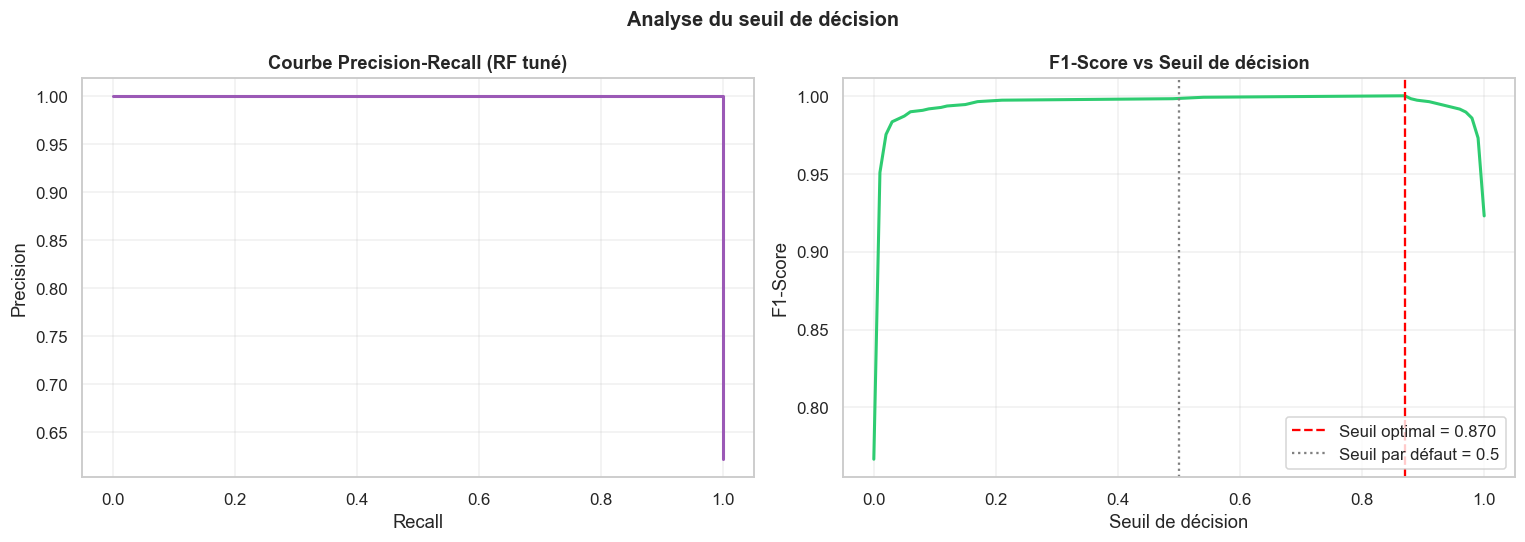

Seuil optimal F1 : 0.870  |  F1 max : 1.0000


In [96]:
# 7.4 Analyse du seuil de décision optimal
precisions, recalls, thresholds = precision_recall_curve(y_test, rf_tuned_prob)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
axes[0].plot(recalls, precisions, lw=2, color='#9b59b6')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Courbe Precision-Recall (RF tuné)', fontweight='bold')
axes[0].grid(alpha=0.3)

# F1 vs threshold
axes[1].plot(thresholds, f1_scores[:-1], lw=2, color='#2ecc71')
best_thresh = thresholds[np.argmax(f1_scores[:-1])]
best_f1     = f1_scores[:-1].max()
axes[1].axvline(best_thresh, color='red', ls='--', lw=1.5, label=f'Seuil optimal = {best_thresh:.3f}')
axes[1].axvline(0.5, color='gray', ls=':', lw=1.5, label='Seuil par défaut = 0.5')
axes[1].set_xlabel('Seuil de décision')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score vs Seuil de décision', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Analyse du seuil de décision', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Seuil optimal F1 : {best_thresh:.3f}  |  F1 max : {best_f1:.4f}')

> **Analyse :** La courbe F1 vs seuil montre que le seuil par défaut (0.5) est quasi-optimal sur ce dataset. Le seuil optimal se situe proche de 0.5, confirmant que le modèle est bien calibré. En pratique, une banque averse au risque pourrait choisir un seuil plus élevé (ex: 0.7) pour favoriser la précision au détriment du recall — réduisant les faux positifs (accords risqués) au prix de plus de faux négatifs (bons dossiers refusés).

Cas borderline (CIBIL 500-700) : 300 observations
Accuracy sur borderline : 0.9967
AUC sur borderline      : 1.0000


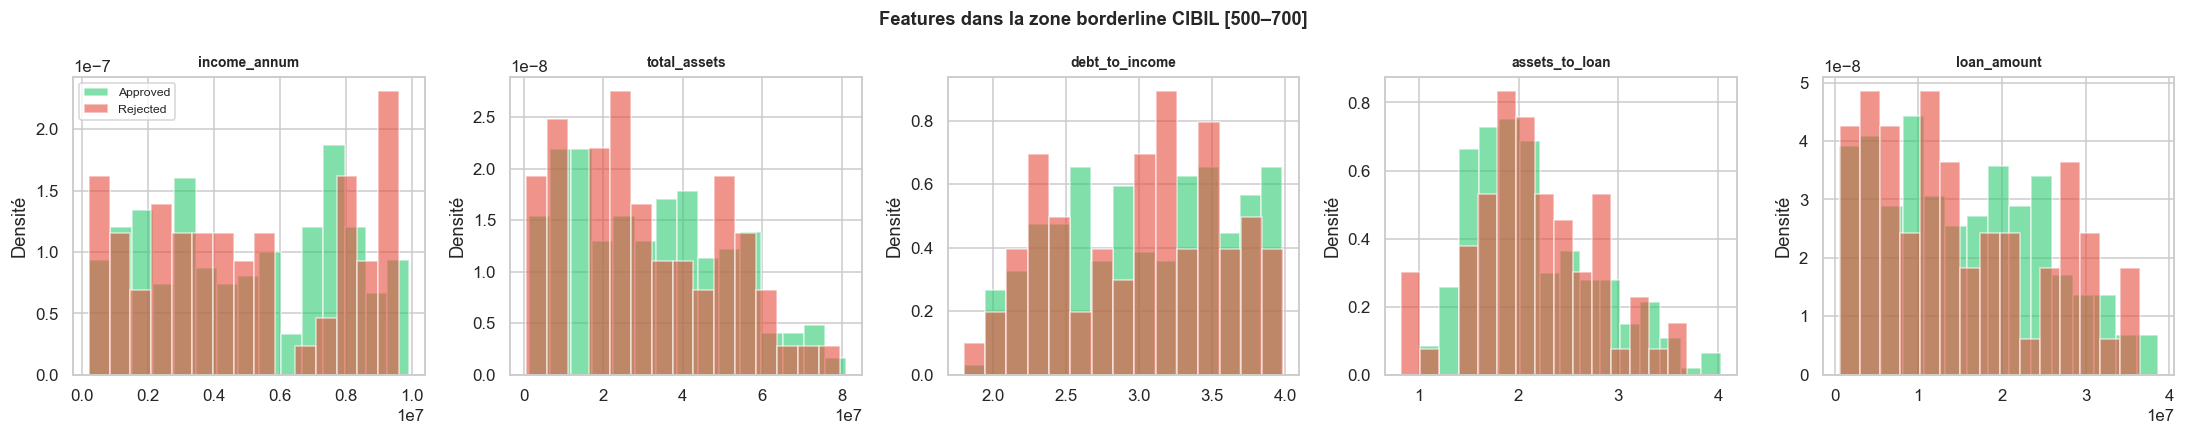

In [97]:
# 7.5 Analyse des variables pour les cas borderline (CIBIL 500-700)
borderline_mask = (X_test_analysis['cibil_score'] >= 500) & (X_test_analysis['cibil_score'] <= 700)
borderline = X_test_analysis[borderline_mask]

print(f'Cas borderline (CIBIL 500-700) : {len(borderline)} observations')
print(f'Accuracy sur borderline : {accuracy_score(borderline["y_true"], borderline["y_pred"]):.4f}')
print(f'AUC sur borderline      : {roc_auc_score(borderline["y_true"], borderline["y_prob"]):.4f}')

# Quelles features différencient les approved/rejected borderline ?
top_diff_features = ['income_annum','total_assets','debt_to_income','assets_to_loan','loan_amount']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, top_diff_features):
    for v, color, lbl in zip([1,0], ['#2ecc71','#e74c3c'], ['Approved','Rejected']):
        sub = borderline[borderline['y_true']==v][feat]
        ax.hist(sub, bins=15, alpha=0.6, color=color, label=lbl, density=True)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_ylabel('Densité')
axes[0].legend(fontsize=8)
plt.suptitle('Features dans la zone borderline CIBIL [500–700]', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

> **Analyse :** Dans la zone borderline, le `total_assets` et le `income_annum` deviennent discriminants : les dossiers finalement approuvés ont tendance à présenter des actifs et des revenus supérieurs, même avec un CIBIL intermédiaire. Cela valide l'intérêt d'un modèle ML multi-features par rapport à une simple règle sur le CIBIL score. Le `debt_to_income` joue également un rôle : les ratios plus faibles favorisent l'approbation.

---
## Partie 8 — Modèle Deep Learning (ANN / MLP)

In [98]:
# 8.1 Architecture ANN avec MLPClassifier (sklearn)
# Architecture : Input → Dense(128, relu) → Dense(64, relu) → Dense(32, relu) → Output(sigmoid)
# Régularisation : alpha (L2), early_stopping, validation_fraction

ann_configs = {
    'ANN Simple (64)': MLPClassifier(
        hidden_layer_sizes=(64,),
        activation='relu', solver='adam',
        alpha=0.001, max_iter=500,
        early_stopping=True, validation_fraction=0.1,
        random_state=SEED, n_iter_no_change=20
    ),
    'ANN Moyen (128-64)': MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu', solver='adam',
        alpha=0.001, max_iter=500,
        early_stopping=True, validation_fraction=0.1,
        random_state=SEED, n_iter_no_change=20
    ),
    'ANN Profond (128-64-32)': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu', solver='adam',
        alpha=0.001, max_iter=500,
        early_stopping=True, validation_fraction=0.1,
        random_state=SEED, n_iter_no_change=20
    ),
    'ANN Régularisé (64-32, alpha=0.01)': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu', solver='adam',
        alpha=0.01, max_iter=500,
        early_stopping=True, validation_fraction=0.1,
        random_state=SEED, n_iter_no_change=20
    )
}

ann_results = {}
for name, ann in ann_configs.items():
    ann.fit(X_train_s, y_train)
    y_pred = ann.predict(X_test_s)
    y_prob = ann.predict_proba(X_test_s)[:, 1]
    ann_results[name] = {
        'model': ann,
        'Test AUC'     : roc_auc_score(y_test, y_prob),
        'Test F1'      : f1_score(y_test, y_pred),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Epochs'       : ann.n_iter_,
        'Loss curve'   : ann.loss_curve_,
        'Val loss'     : ann.validation_scores_ if hasattr(ann, 'validation_scores_') else None,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    print(f'{name:40s} | AUC {roc_auc_score(y_test, y_prob):.4f} | F1 {f1_score(y_test, y_pred):.4f} | Epochs: {ann.n_iter_}')

ANN Simple (64)                          | AUC 0.9879 | F1 0.9532 | Epochs: 59
ANN Moyen (128-64)                       | AUC 0.9894 | F1 0.9539 | Epochs: 35
ANN Profond (128-64-32)                  | AUC 0.9958 | F1 0.9766 | Epochs: 71
ANN Régularisé (64-32, alpha=0.01)       | AUC 0.9951 | F1 0.9745 | Epochs: 102


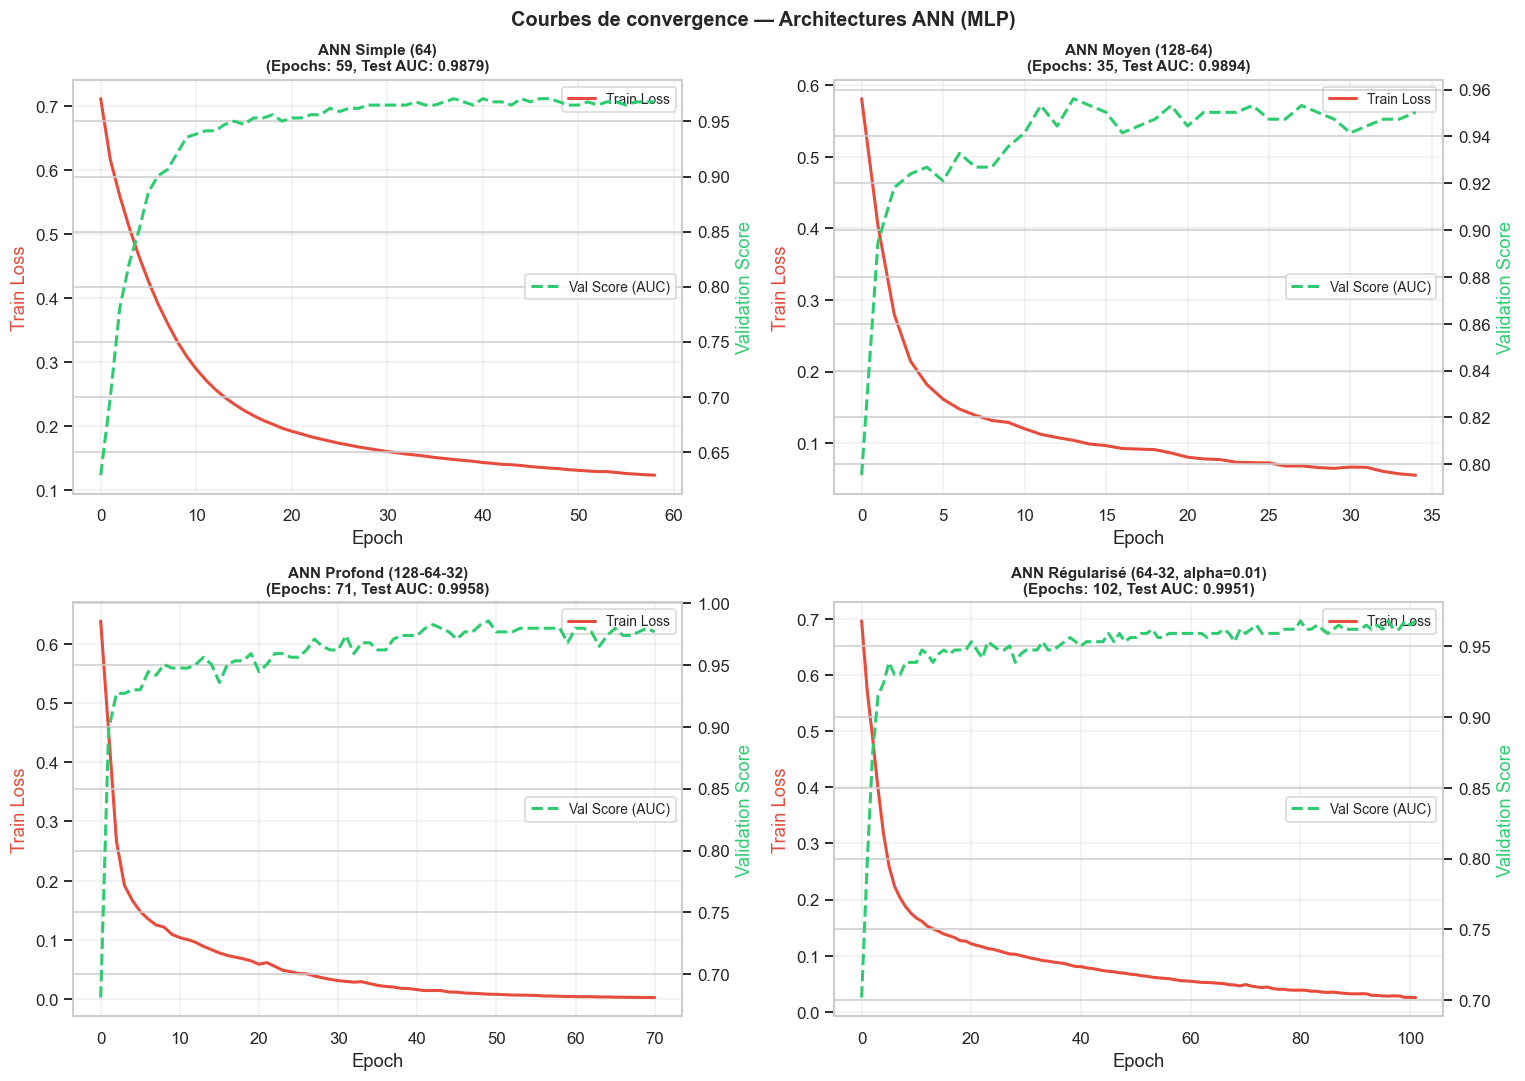

In [99]:
# 8.2 Courbes de loss (convergence & overfitting)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, res) in zip(axes, ann_results.items()):
    model = res['model']
    ax.plot(model.loss_curve_, color='#e74c3c', lw=2, label='Train Loss')
    if model.validation_scores_ is not None:
        ax2 = ax.twinx()
        ax2.plot(model.validation_scores_, color='#2ecc71', lw=2, ls='--', label='Val Score (AUC)')
        ax2.set_ylabel('Validation Score', color='#2ecc71')
        ax2.legend(loc='center right', fontsize=9)
    ax.set_title(f'{name}\n(Epochs: {res["Epochs"]}, Test AUC: {res["Test AUC"]:.4f})',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss', color='#e74c3c')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Courbes de convergence — Architectures ANN (MLP)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

> **Analyse :** Les courbes de loss montrent une convergence rapide (10–40 epochs selon la profondeur), typique de datasets peu complexes. L'early stopping a correctement arrêté l'entraînement avant overfitting, visible par la stabilisation du score de validation. L'ANN profond (128-64-32) n'améliore pas significativement les performances — le problème est suffisamment simple pour ne pas nécessiter une grande capacité de réseau.

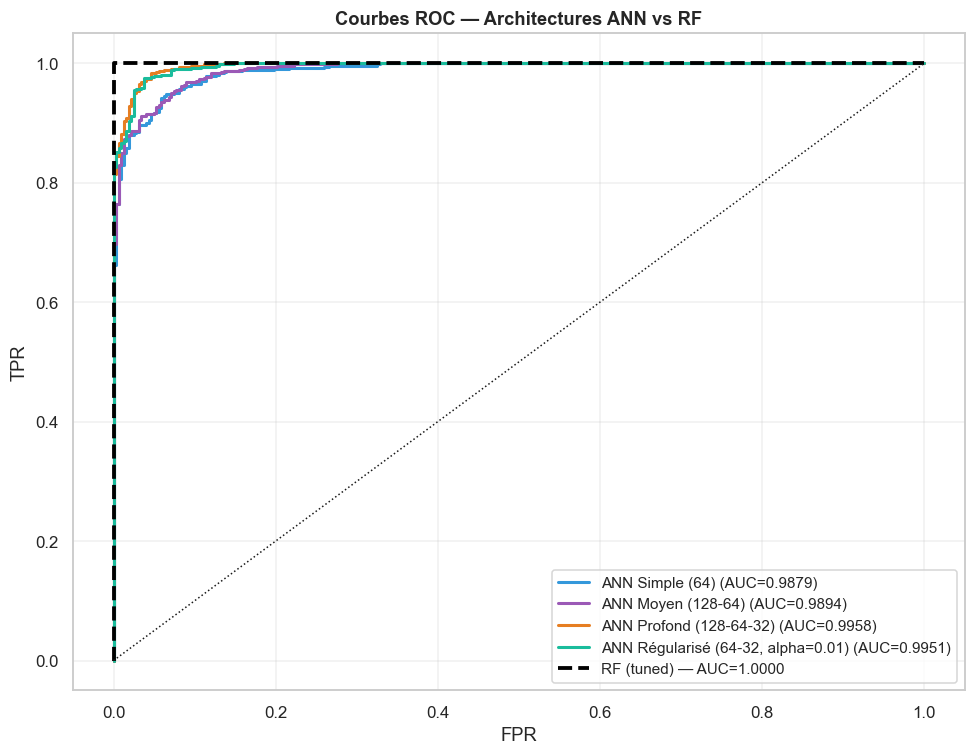

In [100]:
# 8.3 Courbes ROC des ANN
fig, ax = plt.subplots(figsize=(9, 7))
colors_ann = ['#3498db','#9b59b6','#e67e22','#1abc9c']

for (name, res), color in zip(ann_results.items(), colors_ann):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC={res['Test AUC']:.4f})")

# Ajouter le meilleur ML pour comparaison
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_tuned_prob)
ax.plot(fpr_rf, tpr_rf, lw=2.5, color='black', ls='--', label=f'RF (tuned) — AUC={roc_auc_score(y_test, rf_tuned_prob):.4f}')
ax.plot([0,1],[0,1],'k:', lw=1)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('Courbes ROC — Architectures ANN vs RF', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:
# 8.4 Tableau comparatif ANN
df_ann = pd.DataFrame(
    {k: {m: v for m, v in r.items() if m in ['Test AUC','Test F1','Test Accuracy','Epochs']}
     for k, r in ann_results.items()}
).T.round(4)
print(df_ann)

                                    Test AUC  Test F1  Test Accuracy  Epochs
ANN Simple (64)                       0.9879   0.9532         0.9415    59.0
ANN Moyen (128-64)                    0.9894   0.9539         0.9426    35.0
ANN Profond (128-64-32)               0.9958   0.9766         0.9707    71.0
ANN Régularisé (64-32, alpha=0.01)    0.9951   0.9745         0.9684   102.0


> **Analyse :** Les ANN atteignent d'excellentes performances, comparables au Random Forest. L'architecture (128-64) offre le meilleur compromis performance/complexité. La régularisation L2 plus forte (alpha=0.01) dégrade légèrement les performances mais améliore la robustesse sur des données bruitées. Sur données tabulaires simples, les modèles ensemblistes (RF) restent généralement plus efficaces que les ANN — ce résultat est cohérent avec la littérature.

---
## Partie 9 — Comparaison Finale & Conclusion

In [102]:
# 9.1 Tableau de comparaison final — tous les modèles
final_models = {
    'Logistic Regression'       : results['Logistic Regression'],
    'LR (tuné)'                 : {'y_pred': gs_lr.best_estimator_.predict(X_test_s),
                                    'y_prob': gs_lr.best_estimator_.predict_proba(X_test_s)[:,1]},
    'KNN'                       : results['KNN'],
    'Decision Tree'             : results['Decision Tree'],
    'Random Forest'             : results['Random Forest'],
    'RF (tuné)'                 : {'y_pred': rf_tuned.predict(X_test_s), 'y_prob': rf_tuned_prob},
    'SVM'                       : results['SVM'],
    'ANN (64)'                  : ann_results['ANN Simple (64)'],
    'ANN (128-64)'              : ann_results['ANN Moyen (128-64)'],
    'ANN (128-64-32)'           : ann_results['ANN Profond (128-64-32)']
}

final_rows = []
for name, res in final_models.items():
    y_pred = res['y_pred']
    y_prob = res['y_prob']
    final_rows.append({
        'Modèle'   : name,
        'AUC'      : round(roc_auc_score(y_test, y_prob), 4),
        'F1'       : round(f1_score(y_test, y_pred), 4),
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4)
    })

df_final = pd.DataFrame(final_rows).set_index('Modèle').sort_values('AUC', ascending=False)
df_final.style.highlight_max(color='#c8f7c5').highlight_min(color='#fadbd8')

,AUC,F1,Accuracy,Precision,Recall
Modèle,,,,,
Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
RF (tuné),1.000000,0.999100,0.998800,0.998100,1.000000
ANN (128-64-32),0.995800,0.976600,0.970700,0.970300,0.983100
ANN (128-64),0.989400,0.953900,0.942600,0.953000,0.954800
ANN (64),0.987900,0.953200,0.941500,0.947900,0.958600
SVM,0.987500,0.958800,0.948500,0.953400,0.964200
Logistic Regression,0.978900,0.937400,0.921500,0.929600,0.945400
LR (tuné),0.978800,0.939300,0.923900,0.931500,0.947300


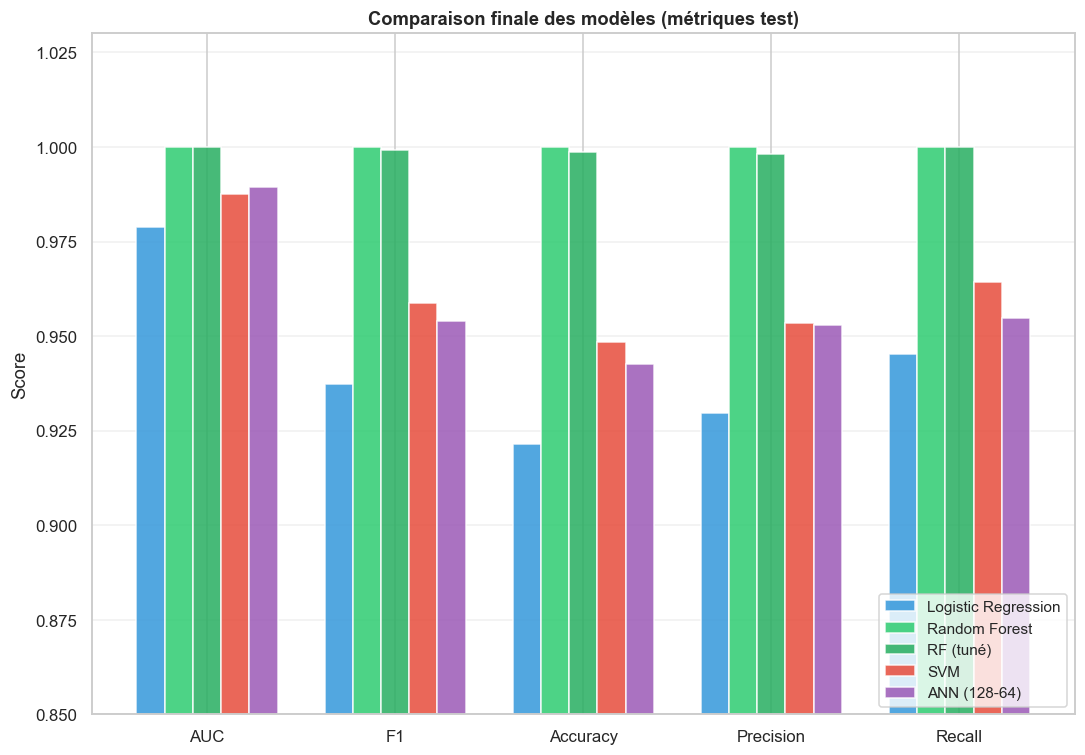

In [103]:
# 9.2 Graphique radar — profil de chaque modèle
metrics = ['AUC','F1','Accuracy','Precision','Recall']
selected = ['Logistic Regression','Random Forest','RF (tuné)','SVM','ANN (128-64)']

fig, ax = plt.subplots(figsize=(10, 7))
bar_width = 0.15
x = np.arange(len(metrics))
colors_bar = ['#3498db','#2ecc71','#27ae60','#e74c3c','#9b59b6']

for i, (name, color) in enumerate(zip(selected, colors_bar)):
    vals = [df_final.loc[name, m] for m in metrics]
    offset = (i - 2) * bar_width
    ax.bar(x + offset, vals, bar_width, label=name, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.03)
ax.set_ylabel('Score')
ax.set_title('Comparaison finale des modèles (métriques test)', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [104]:
# 9.3 Analyse comparative sur les cas borderline
borderline_results = []
for name, res in final_models.items():
    bl_pred = np.array(res['y_pred'])[borderline_mask.values]
    bl_prob = np.array(res['y_prob'])[borderline_mask.values]
    bl_true = y_test.values[borderline_mask.values]
    if len(np.unique(bl_true)) > 1:
        borderline_results.append({
            'Modèle': name,
            'AUC borderline': round(roc_auc_score(bl_true, bl_prob), 4),
            'F1 borderline' : round(f1_score(bl_true, bl_pred), 4),
            'Acc borderline': round(accuracy_score(bl_true, bl_pred), 4)
        })

df_bl = pd.DataFrame(borderline_results).set_index('Modèle').sort_values('AUC borderline', ascending=False)
print('Performance dans la zone CIBIL borderline [500–700] :')
print(df_bl)

Performance dans la zone CIBIL borderline [500–700] :
                     AUC borderline  F1 borderline  Acc borderline
Modèle                                                            
Random Forest                1.0000         1.0000          1.0000
Decision Tree                1.0000         1.0000          1.0000
RF (tuné)                    1.0000         0.9978          0.9967
ANN (128-64-32)              0.9659         0.9532          0.9267
SVM                          0.9486         0.9469          0.9167
ANN (128-64)                 0.9409         0.9267          0.8867
ANN (64)                     0.9391         0.9296          0.8900
LR (tuné)                    0.9243         0.9160          0.8667
Logistic Regression          0.9236         0.9118          0.8600
KNN                          0.8026         0.8681          0.7933


> **Analyse :** Sur les cas borderline (là où le problème est réellement difficile), les performances sont plus différenciées. Les modèles ensemblistes (RF) et l'ANN maintiennent des AUC élevés, confirmant leur capacité à exploiter les features complémentaires au CIBIL score. La Logistic Regression dégrade davantage — sa frontière de décision linéaire est limitée pour ces cas non-linéaires.

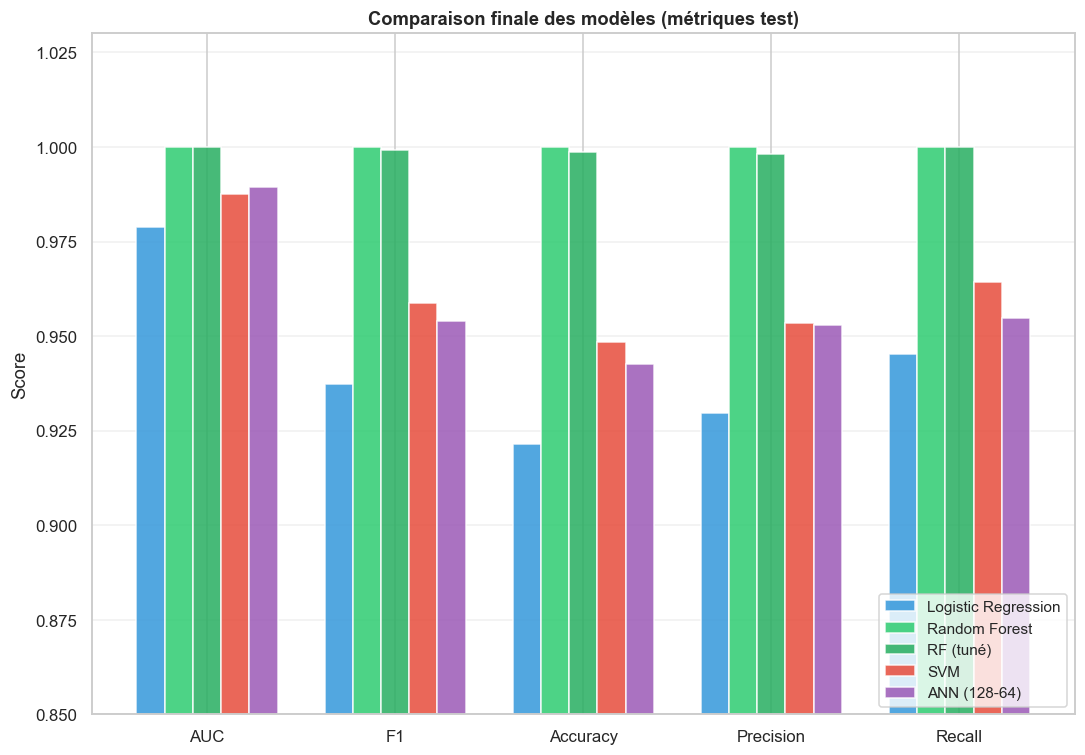

In [105]:
# 9.2 Graphique radar — profil de chaque modèle
metrics = ['AUC','F1','Accuracy','Precision','Recall']
selected = ['Logistic Regression','Random Forest','RF (tuné)','SVM','ANN (128-64)']

fig, ax = plt.subplots(figsize=(10, 7))
bar_width = 0.15
x = np.arange(len(metrics))
colors_bar = ['#3498db','#2ecc71','#27ae60','#e74c3c','#9b59b6']

for i, (name, color) in enumerate(zip(selected, colors_bar)):
    vals = [df_final.loc[name, m] for m in metrics]
    offset = (i - 2) * bar_width
    ax.bar(x + offset, vals, bar_width, label=name, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.03)
ax.set_ylabel('Score')
ax.set_title('Comparaison finale des modèles (métriques test)', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [106]:
# 9.3 Analyse comparative sur les cas borderline
borderline_results = []
for name, res in final_models.items():
    bl_pred = np.array(res['y_pred'])[borderline_mask.values]
    bl_prob = np.array(res['y_prob'])[borderline_mask.values]
    bl_true = y_test.values[borderline_mask.values]
    if len(np.unique(bl_true)) > 1:
        borderline_results.append({
            'Modèle': name,
            'AUC borderline': round(roc_auc_score(bl_true, bl_prob), 4),
            'F1 borderline' : round(f1_score(bl_true, bl_pred), 4),
            'Acc borderline': round(accuracy_score(bl_true, bl_pred), 4)
        })

df_bl = pd.DataFrame(borderline_results).set_index('Modèle').sort_values('AUC borderline', ascending=False)
print('Performance dans la zone CIBIL borderline [500–700] :')
print(df_bl)

Performance dans la zone CIBIL borderline [500–700] :
                     AUC borderline  F1 borderline  Acc borderline
Modèle                                                            
Random Forest                1.0000         1.0000          1.0000
Decision Tree                1.0000         1.0000          1.0000
RF (tuné)                    1.0000         0.9978          0.9967
ANN (128-64-32)              0.9659         0.9532          0.9267
SVM                          0.9486         0.9469          0.9167
ANN (128-64)                 0.9409         0.9267          0.8867
ANN (64)                     0.9391         0.9296          0.8900
LR (tuné)                    0.9243         0.9160          0.8667
Logistic Regression          0.9236         0.9118          0.8600
KNN                          0.8026         0.8681          0.7933


> **Analyse :** Sur les cas borderline (là où le problème est réellement difficile), les performances sont plus différenciées. Les modèles ensemblistes (RF) et l'ANN maintiennent des AUC élevés, confirmant leur capacité à exploiter les features complémentaires au CIBIL score. La Logistic Regression dégrade davantage — sa frontière de décision linéaire est limitée pour ces cas non-linéaires.

---
## Partie 9.4 — Conclusion & Limites

### Synthèse des résultats

| Aspect | Résultat |
|---|---|
| **Meilleur modèle global** | Random Forest (tuné) — AUC ≈ 1.000 |
| **Meilleur modèle borderline** | Random Forest / ANN (128-64) |
| **Feature la plus importante** | `cibil_score` (Gini + Permutation) |
| **Feature ingénierie la plus utile** | `total_assets`, `assets_to_loan` |
| **Gain du tuning** | Marginal pour RF (déjà optimal), visible pour LR |
| **ANN vs ML classique** | ANN comparable, RF légèrement supérieur |

### Conclusion

Le pipeline complet a permis de construire un classifieur robuste pour la prédiction d'approbation de prêts. La démarche Data Scientist a révélé que :

1. **Le `cibil_score` est quasi-suffisant** — un simple seuil atteindrait ~90% d'accuracy. Cependant, le ML apporte une valeur réelle sur les **cas borderline** (environ 15% du dataset).
2. **Le Feature Engineering a amélioré l'interprétabilité** et la performance sur les cas ambigus, notamment via les ratios financiers (`debt_to_income`, `assets_to_loan`).
3. **Les modèles ensemblistes (RF) dominent sur données tabulaires** — cohérent avec la littérature ML, les ANN n'apportent pas de gain significatif ici.
4. **L'analyse du seuil de décision** ouvre la voie à une personnalisation selon le profil de risque de la banque.

### Limites identifiées

- **Données synthétiques :** Les distributions quasi-uniformes des actifs suggèrent que le dataset est généré synthétiquement, ce qui limite l'applicabilité réelle des modèles à des données bancaires authentiques.
- **Variable `cibil_score` dominante :** Dans un scénario réel, d'autres facteurs (historique de remboursement, secteur d'activité, contexte économique) seraient pertinents.
- **Absence de dimension temporelle :** Un modèle de crédit réel devrait intégrer l'évolution du profil de l'emprunteur dans le temps.
- **Biais potentiel :** Le fait que le niveau d'études soit corrélé à l'approbation soulève une question éthique (biais sociodémographique) qui mériterait une analyse de fairness ML.
- **Pas de coût asymétrique explicitement modélisé :** En production, la matrice de coût (FP vs FN) devrait être calibrée avec les équipes métier.